## 006 - AppleCider multimodal
<a id='index'></a> <br>

- [part 0: config](#config)
- [part 1: DataGenerator](#data)
    - [example object in Dataset (includes alert.npy)](#ex)
    - [processed photometry vs normalized flux in dataset](#process)
    - [plot photometry, images, spectra, (metadata is also there)](#stuff)
- [part 2: DataLoader](#dataload)


In [1]:
import os
import sys
sys.path.insert(0, '/Users/junell/Documents/AppleCider')

import joblib
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy import stats
from datetime import datetime
import wandb
from tqdm.auto import tqdm
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

## so many plots
import AppleCider.preprocess.plot_data as plot_data
from AppleCider.preprocess.plot_data import plot_image
import AppleCider.preprocess.more_info as more_info
from AppleCider.preprocess.plot_data import plot_dataset

## model stuff
from AppleCider.core.model import Informer, GalSpecNet, MetaModel, BTSModel, AstroM4

from AppleCider.core.dataset import DataGenerator

from tqdm.auto import tqdm
import pickle

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch import nn
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau, LinearLR


import AppleCider.core.drink as drink

#import optuna 
#from optuna.exceptions import DuplicatedStudyError

In [2]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
data_dir = '/Users/junell/Documents/AppleCider_Data/SEDM_folder'

data_test = pd.read_csv('/Users/junell/Documents/AppleCider/data_test.csv')
data_train = pd.read_csv('/Users/junell/Documents/AppleCider/data_train.csv')

SEDM_dataset = pd.read_csv('/Users/junell/Documents/AppleCider/SEDM_dataset.csv')

In [3]:
TRAIN_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_train'
TEST_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_test'

In [4]:
## obj_id, type for every object with SEDM spectra
SEDM_dataset[:2]

,obj_id,type
0,ZTF18aatfxtd,SN Ia
1,ZTF18aawppyt,SN Ia


In [5]:
## obj_id, alert file name, type
data_train[:2]

,name,file,type
0,ZTF17aaajnki,ZTF17aaajnki_alert_2.npy,AGN
1,ZTF17aaaukqn,ZTF17aaaukqn_alert_10.npy,Cataclysmic


In [6]:
print(len(data_train))
print(len(data_test))

9635
1878


In [7]:
data_train['type'].value_counts()

type
SN Ia                     2470
SN II                     2069
SN IIP                    1705
Cataclysmic               1203
SN IIn                     625
SN Ic                      449
SN Ib                      413
SN IIb                     315
AGN                        314
Tidal Disruption Event      72
Name: count, dtype: int64

<big>part 0: config</big>

<a id='config'></a>

<u>what paths / files do i need?</u>
- stuff you just need:
    - `SEDM_folder` which you can get from Google Drive, link in the README of repo <3
- stuff you can get from the data pre-processing steps:
    - data_train.csv (`df_path`) created in `001-data-processing.ipynb`. <small>(included in the repo) </small>
    - preprocessed data (`preprocessed_path`) <small>not in repo but i'll upload to github (lmk if this link doesn't work)</small>
    - train_files.pkl (`train_files_path`) & val_files.pkl (`val_files_path`) created in `001-data-processing.ipynb`. <small>(included in the repo) </small>
    - scaler.pkl (`scaler_path`) created in `003-AppleCider-metadata.ipynb`. <small>(included in the repo) </small>
    
<i><small>[back to index](#index)</small></i>

In [8]:
config = {
        'project': 'AppleCider',
        'mode': 'all',    # 'clip' 'photo' 'spectra' 'meta' 'image' 'all'
        'config_from': None,
        'random_seed': 42,  # 42, 66, 0, 12, 123
        'use_wandb': True,
        'save_weights': False,
        'weights_path': f'/Users/junell/Documents/AppleCider/weights/{datetime.now().strftime("%Y-%m-%d-%H-%M")}',
        'use_pretrain': None,
        'freeze': False,

        # Data General
        'preprocessed_path':'/Users/junell/Documents/AppleCider_Data/data_train',
        'df_path': '/Users/junell/Documents/AppleCider/data_train.csv',
        
        # save train, val file names ...
        'train_files_path': '/Users/junell/Documents/AppleCider/train_files.pkl',
        'val_files_path': '/Users/junell/Documents/AppleCider/val_files.pkl',
        
        'step': 'type',
        'classes': CLASSES,
        'group_labels': True,
        'max_samples': 1000,
        'num_classes': len(CLASSES),

        # Photometry Model
        'seq_len': 225,
        'p_enc_in': 4,
        'p_d_model': 4,
        'p_dropout': 0.2,
        'p_factor': 1,
        'p_output_attention': False,
        'p_n_heads': 4,
        'p_d_ff': 512,
        'p_activation': 'gelu',
        'p_e_layers': 8,

        # Spectra Model
        's_dropout': 0.2, 
        's_conv_channels': [1, 64, 64, 32, 32],
        's_kernel_size': 3,
        's_mp_kernel_size': 4,

        # Metadata Model
        'm_hidden_dim': 512,
        'm_dropout': 0.2,
        'meta_cols': range(10),
        'scaler_path': '/Users/junell/Documents/AppleCider/AppleCider/core/scaler.pkl',

        # Image Model
        'input_channels': 3,
        'conv1_channels': 64,
        'conv2_channels': 16,
        'conv_kernel': 3,
        'conv_dropout1': 0.45,
        'conv_dropout2': 0.65,

        # MultiModal Model
        'hidden_dim': 512,
        'fusion': 'avg',  # 'avg', 'concat'

        # Training
        'batch_size': 512,
        'lr': 0.001,
        'beta1': 0.9,
        'beta2': 0.999,
        'weight_decay': 0.01,
        'epochs':25,
        #'epochs': 100, 
        'early_stopping_patience': 10,
        #'early_stopping_patience': 60,
        'scheduler': 'ReduceLROnPlateau',  # 'ExponentialLR', 'ReduceLROnPlateau'
        'gamma': 0.9,  # for ExponentialLR scheduler
        'factor': 0.3,  # for ReduceLROnPlateau scheduler
        'patience': 3,  # for ReduceLROnPlateau scheduler
        'warmup': False,
        'warmup_epochs': 100,
        'clip_grad': False,
        'clip_value': 5
    }

In [9]:
wandb.init(
    project=config['project'],
    config=config, group='2_24',
    job_type='train')

wandb: Currently logged in as: ajunell (ajunell-university-of-minnesota) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
/Users/junell/opt/anaconda3/lib/python3.8/site-packages/pydantic/main.py:314: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Users/junell/opt/anaconda3/lib/python3.8/site-packages/pydantic/main.py:314: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


<a id='Dataset'></a> <br>

<br>

<big>part 1: Dataset</big>


***

<i><small>[back to index](#index)</small></i>

In [10]:
train_dataset = DataGenerator(config=config, split='train')
val_dataset = DataGenerator(config=config, split='val')

<a id='ex'></a>

example object

In [11]:
## you can get the object id from this: 
obj_alert = more_info.give_me_the_original_ish_alert(train_dataset, 2, data_train, TRAIN_DATA_PATH)

obj_id = obj_alert['obj_id']
print(f"ex photometry for {obj_id}:")
photometry = train_dataset[2][0][:13]
photometry

ex photometry for ZTF17aaaukqn:


tensor([[ 0.0000,  1.2316, -0.9936,  0.0000],
        [ 0.0271, -0.9892,  1.1610,  0.0000],
        [ 0.9740, -0.9892,  1.1349,  0.0000],
        [ 1.0020,  1.2712, -0.9936,  0.0000],
        [ 1.9847, -0.9892,  0.8568,  0.0000],
        [ 1.9918,  0.9386, -0.9936,  0.0000],
        [ 2.9745, -0.9892,  1.0266,  0.0000],
        [ 3.0138,  0.7160, -0.9936,  0.0000],
        [ 3.9790, -0.9892,  1.0697,  0.0000],
        [ 4.0045,  0.9934, -0.9936,  0.0000],
        [ 5.0076,  0.7844, -0.9936,  0.0000],
        [ 5.0181, -0.9892,  0.7128,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

In [12]:
print(f"processed alert photometry for {obj_id}:")
obj_alert['photometry']

#obj_alert['metadata']
#obj_alert['images']
#obj_alert['spectra']
#obj_alert['target']
#obj_alert['alert']

processed alert photometry for ZTF17aaaukqn:


array([[ 0.        ,  1.23159594, -0.99362905,  0.        ],
       [ 0.0271412 , -0.98921689,  1.16095013,  0.        ],
       [ 0.9740162 , -0.98921689,  1.13491635,  0.        ],
       [ 1.0019907 ,  1.27121646, -0.99362905,  0.        ],
       [ 1.9847338 , -0.98921689,  0.85684392,  0.        ],
       [ 1.991794  ,  0.93862619, -0.99362905,  0.        ],
       [ 2.974456  , -0.98921689,  1.02661119,  0.        ],
       [ 3.0137963 ,  0.71604782, -0.99362905,  0.        ],
       [ 3.9789815 , -0.98921689,  1.06967327,  0.        ],
       [ 4.0044676 ,  0.99336626, -0.99362905,  0.        ],
       [ 5.0075694 ,  0.78444866, -0.99362905,  0.        ],
       [ 5.0180671 , -0.98921689,  0.71277946,  0.        ]])

<a id='process'></a>

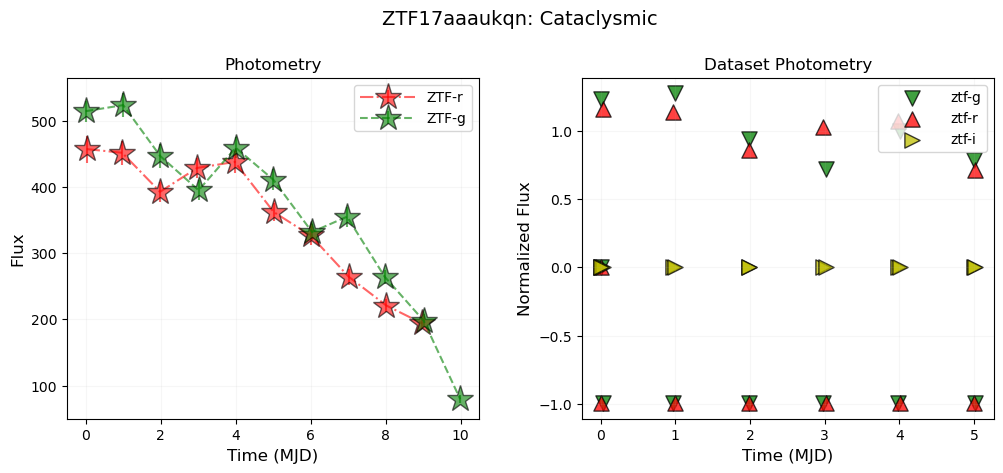

In [13]:
## plot 1 is the original photometry, cut off at 10 days
plot_dataset.compare_dataset_photometry(photometry, obj_id, SEDM_dataset, data_dir)

<a id='stuff'></a>

ZTF17aaaukqn: ZTF17aaaukqn_alert_11.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0529,  0.1169, -1.0099,  0.0804, -1.5322,  1.1025,  0.1593, -0.0156,
         1.0149,  0.1021])


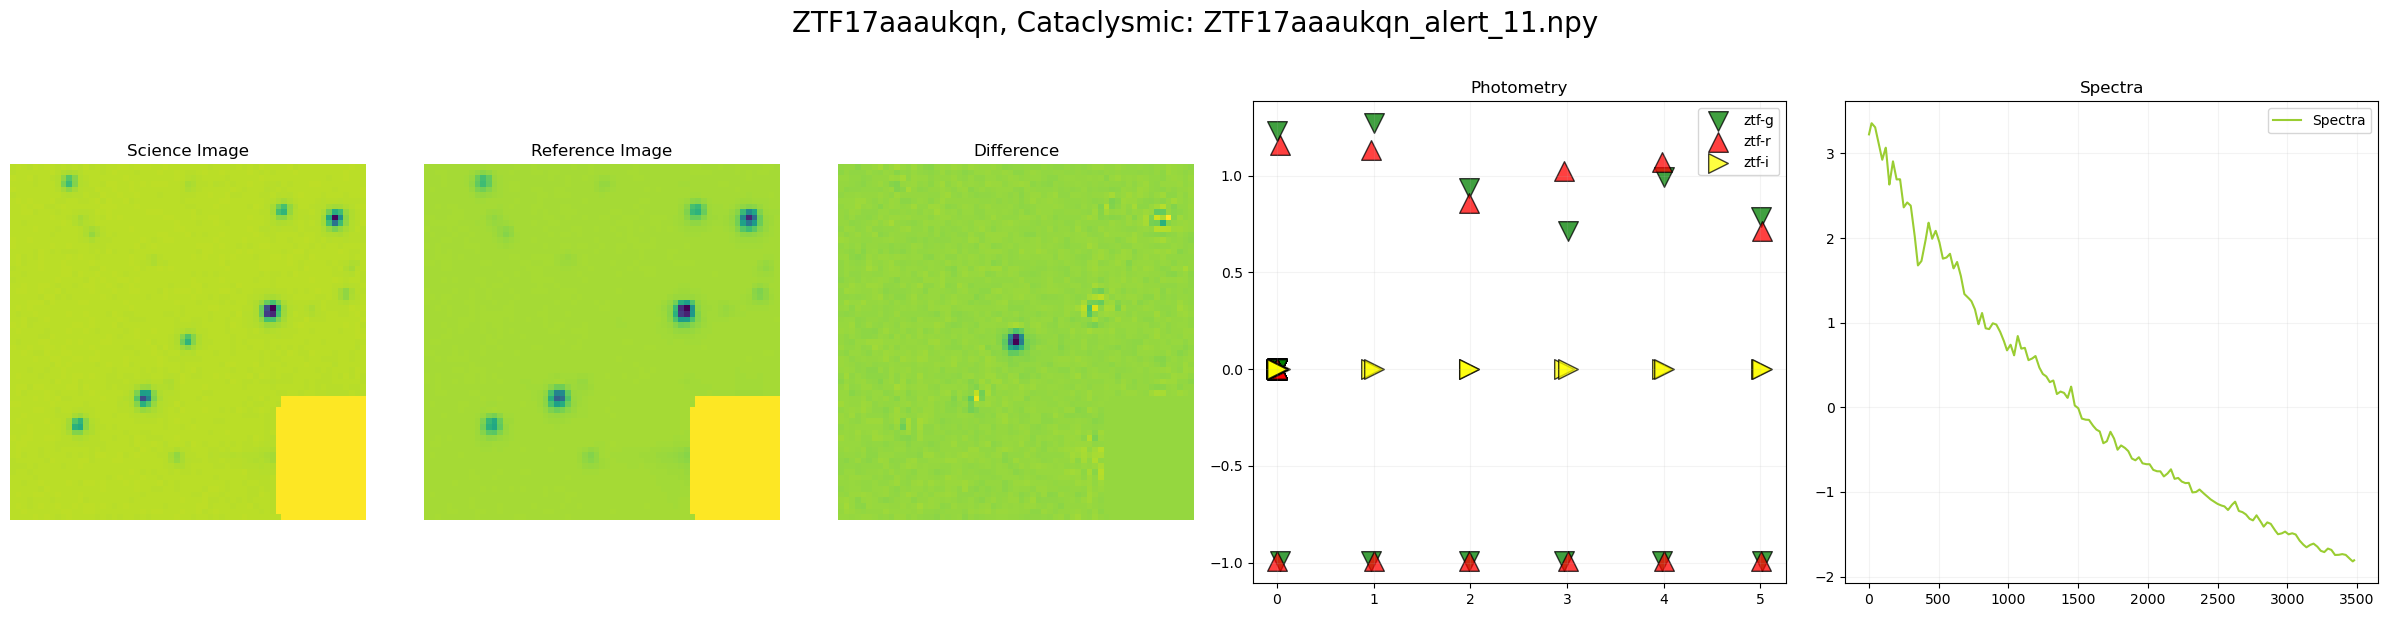

In [14]:
plot_dataset.plot_dataset_item(train_dataset, 2, data_train)

ZTF17aadcbei: ZTF17aadcbei_alert_6.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0598,  0.1088,  1.3050,  0.1249, -0.8511,  0.3047,  0.0931, -0.0135,
        -0.5719, -0.5649])


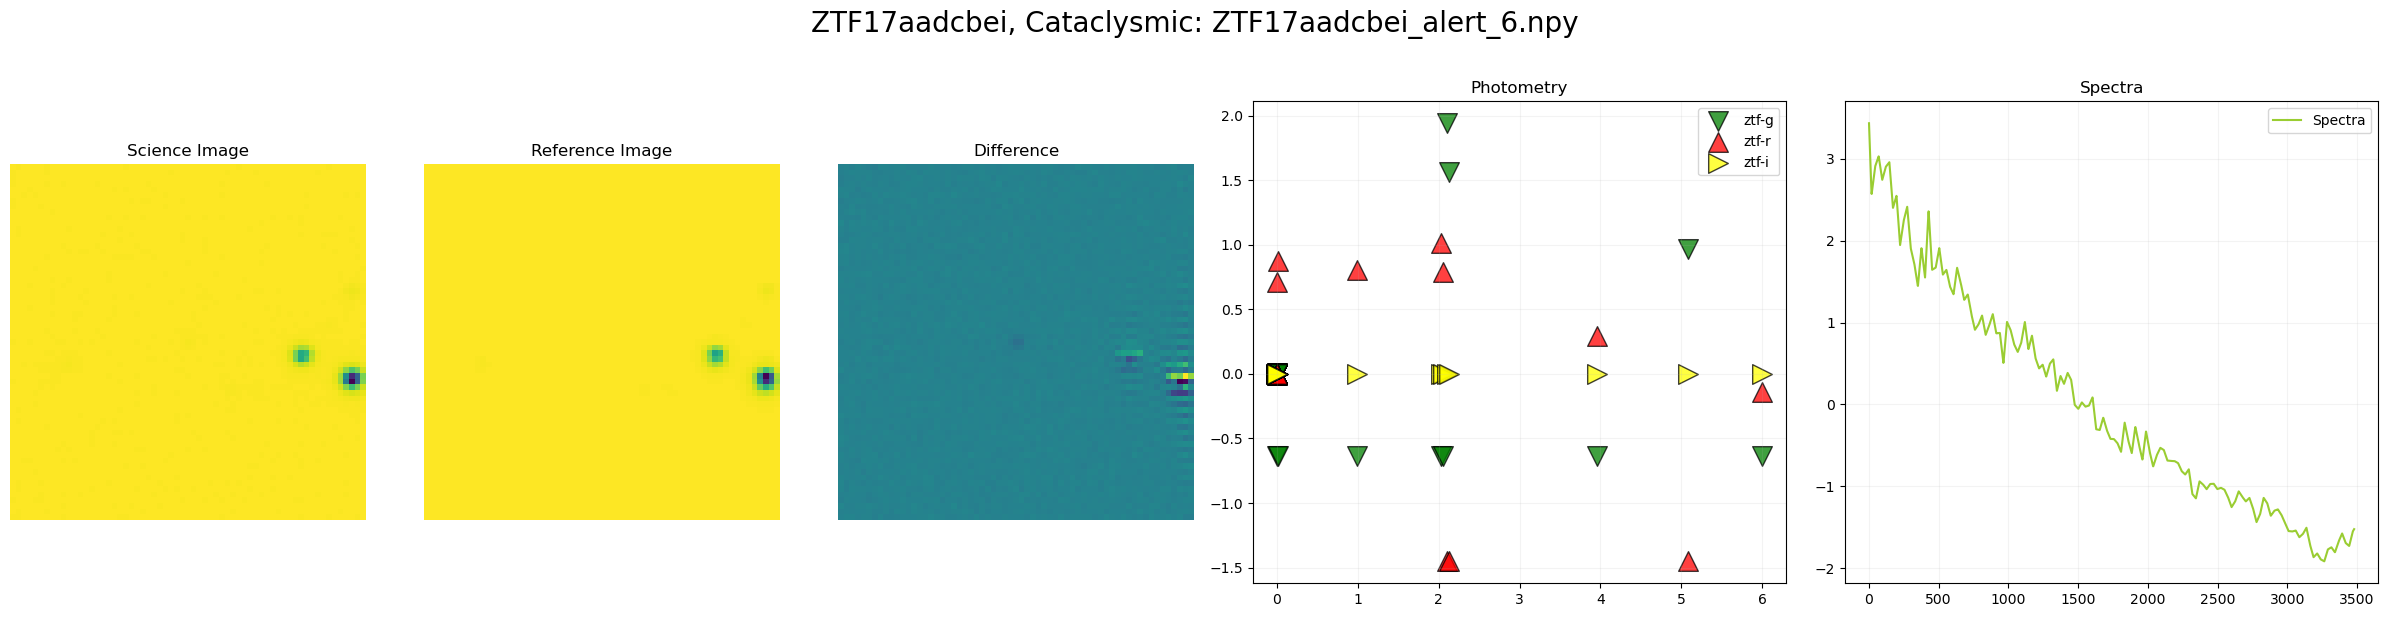

ZTF17aadcbei: ZTF17aadcbei_alert_7.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 5.9757e-02,  1.0878e-01,  1.3036e+00,  1.2658e-01, -8.5114e-01,
         3.0473e-01,  7.0975e-02,  7.5664e-04, -6.2178e-01, -1.6398e+00])


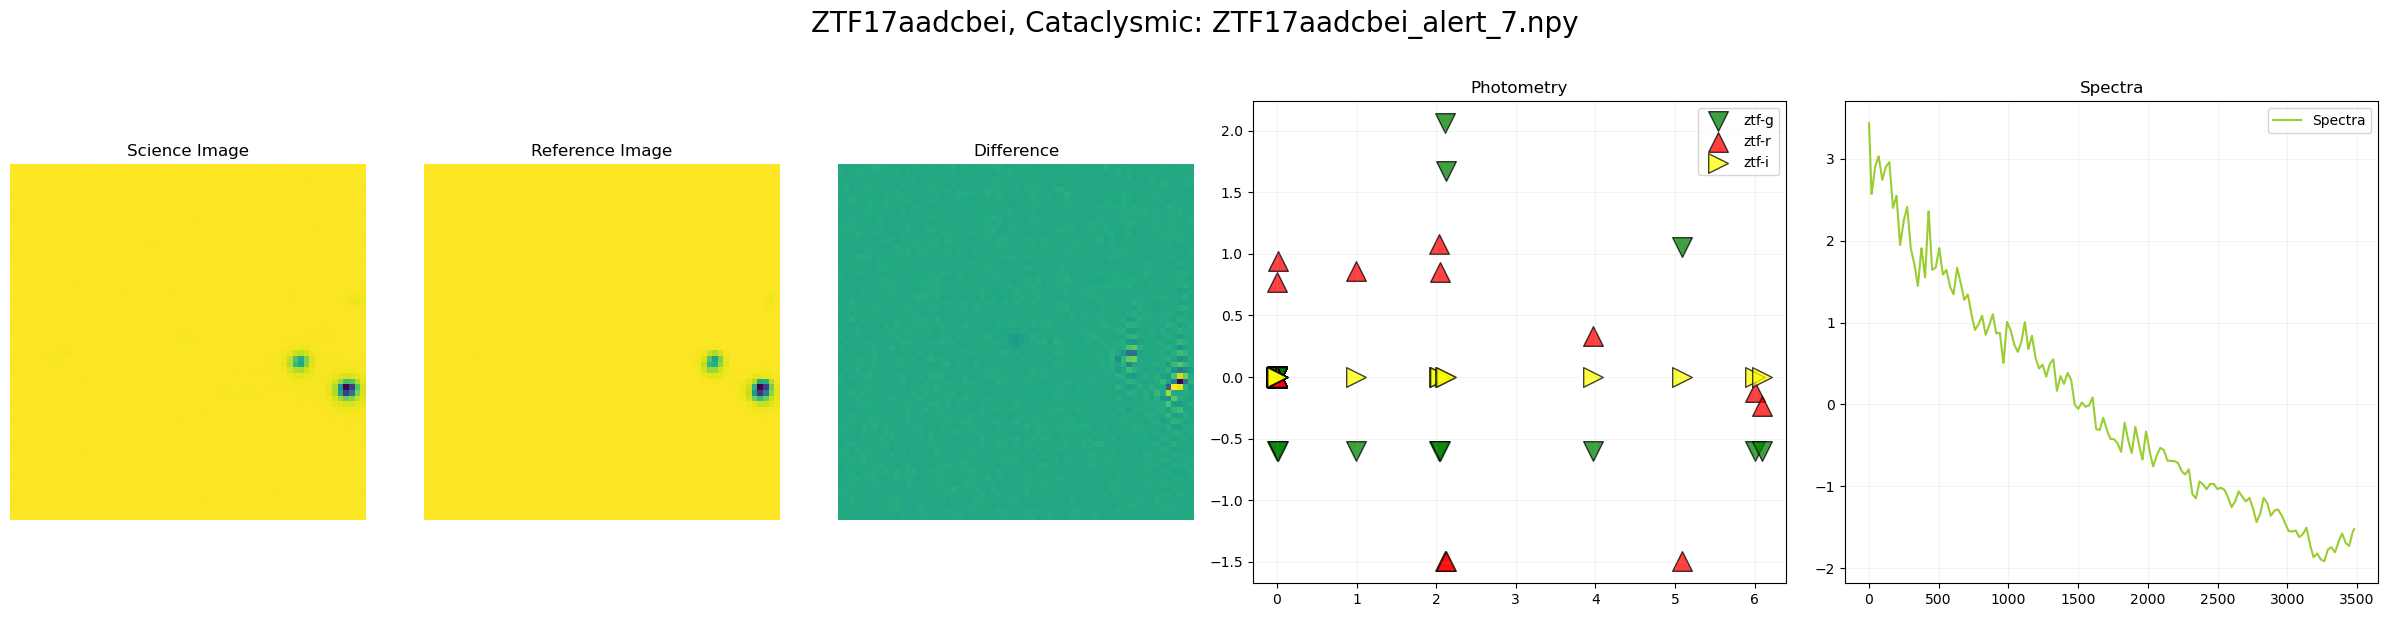

ZTF17aadcbei: ZTF17aadcbei_alert_8.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0598,  0.1088,  1.3229,  0.1255, -0.8511,  0.3047,  0.0710, -0.0259,
        -0.1723,  0.1055])


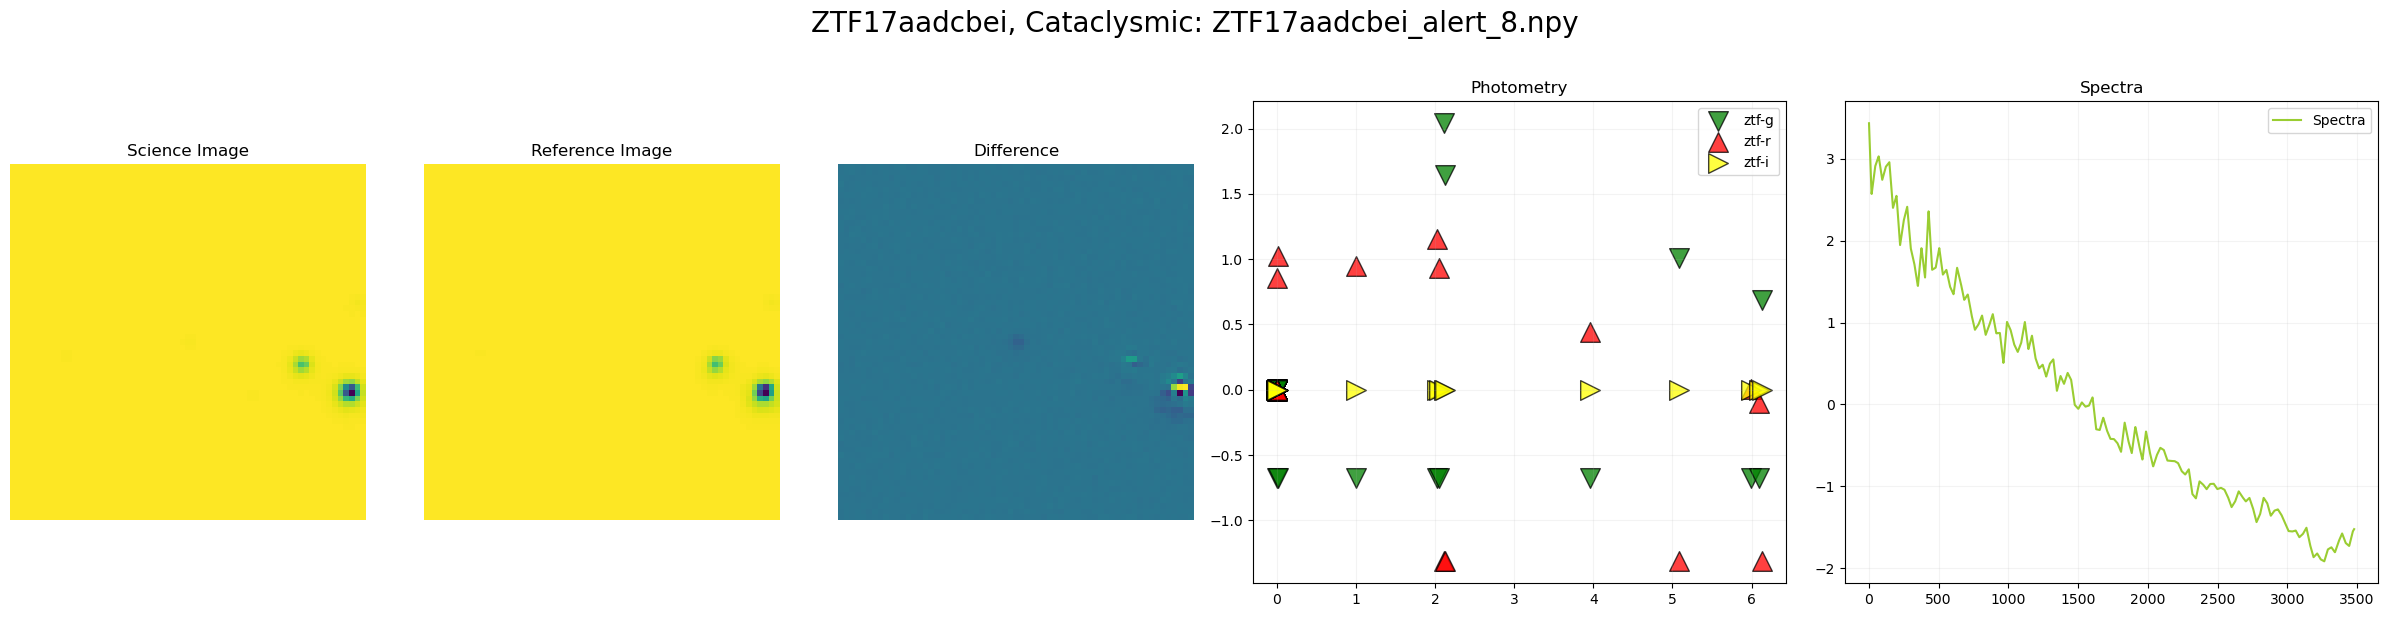

ZTF17aadcbei: ZTF17aadcbei_alert_9.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 4.2272e-02,  1.1706e-01, -9.5688e-01,  1.6255e-01, -1.1137e+00,
         1.2644e+00, -1.7344e-02, -2.7106e-02, -6.4320e-01, -3.0826e-05])


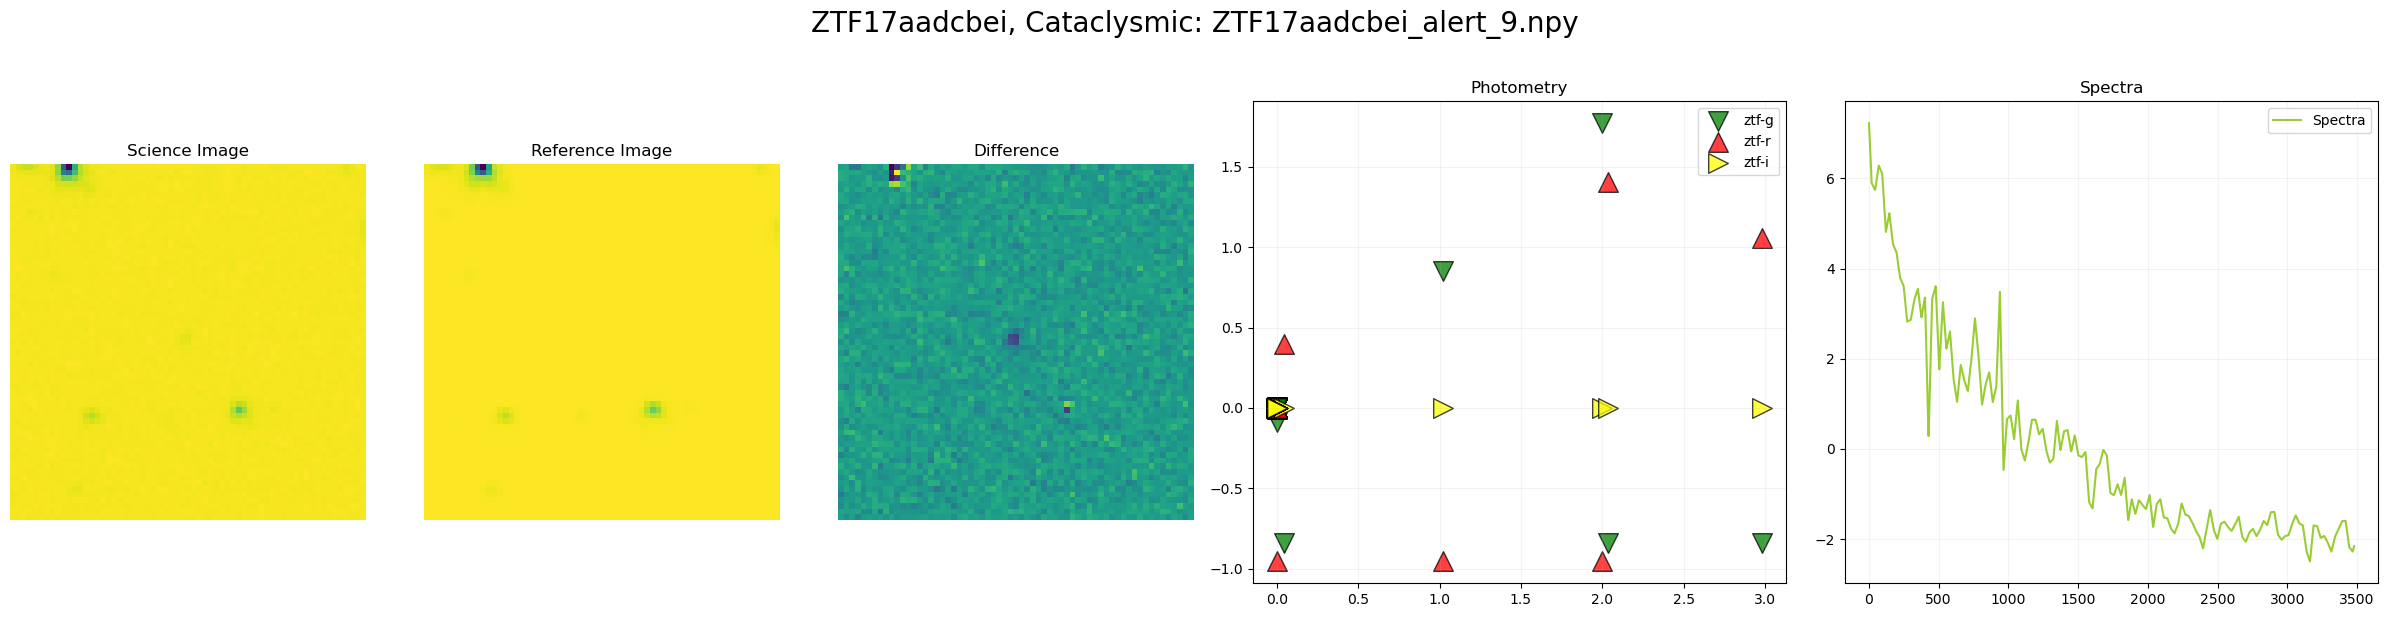

ZTF18aaakpbx: ZTF18aaakpbx_alert_4.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0423,  0.1171, -0.9887,  0.1653, -1.1137,  1.2644, -0.0173, -0.0271,
        -0.5545,  0.8985])


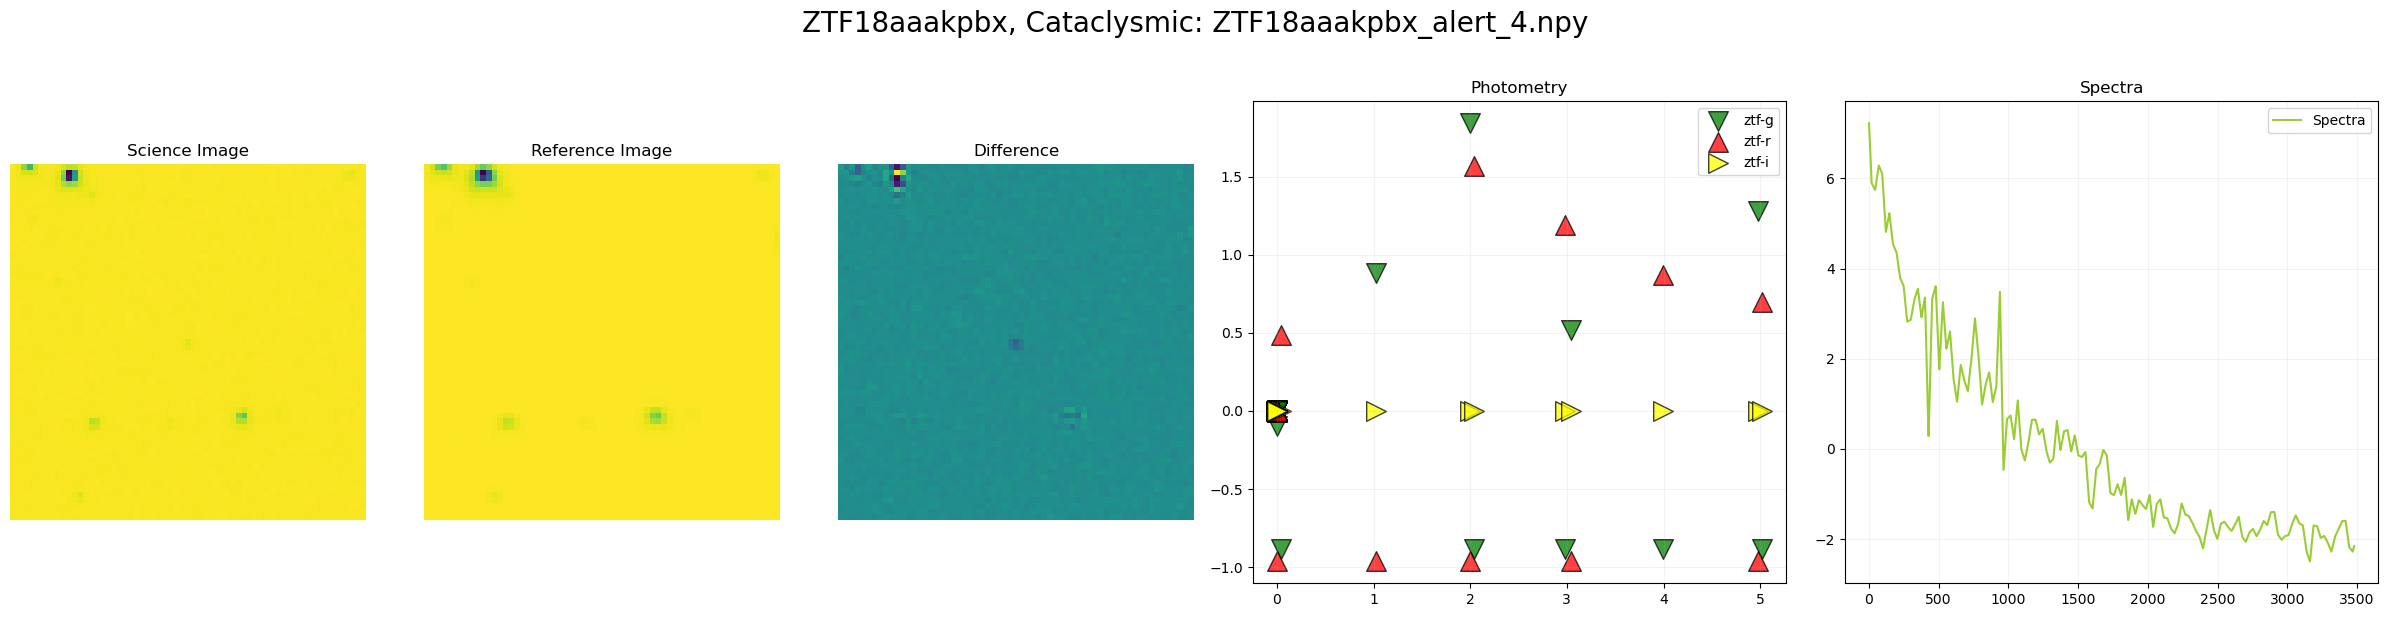

ZTF18aaakpbx: ZTF18aaakpbx_alert_5.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0423,  0.1171, -0.9689,  0.1635, -1.1137,  1.2644, -0.0173, -0.0271,
        -0.7042, -0.0374])


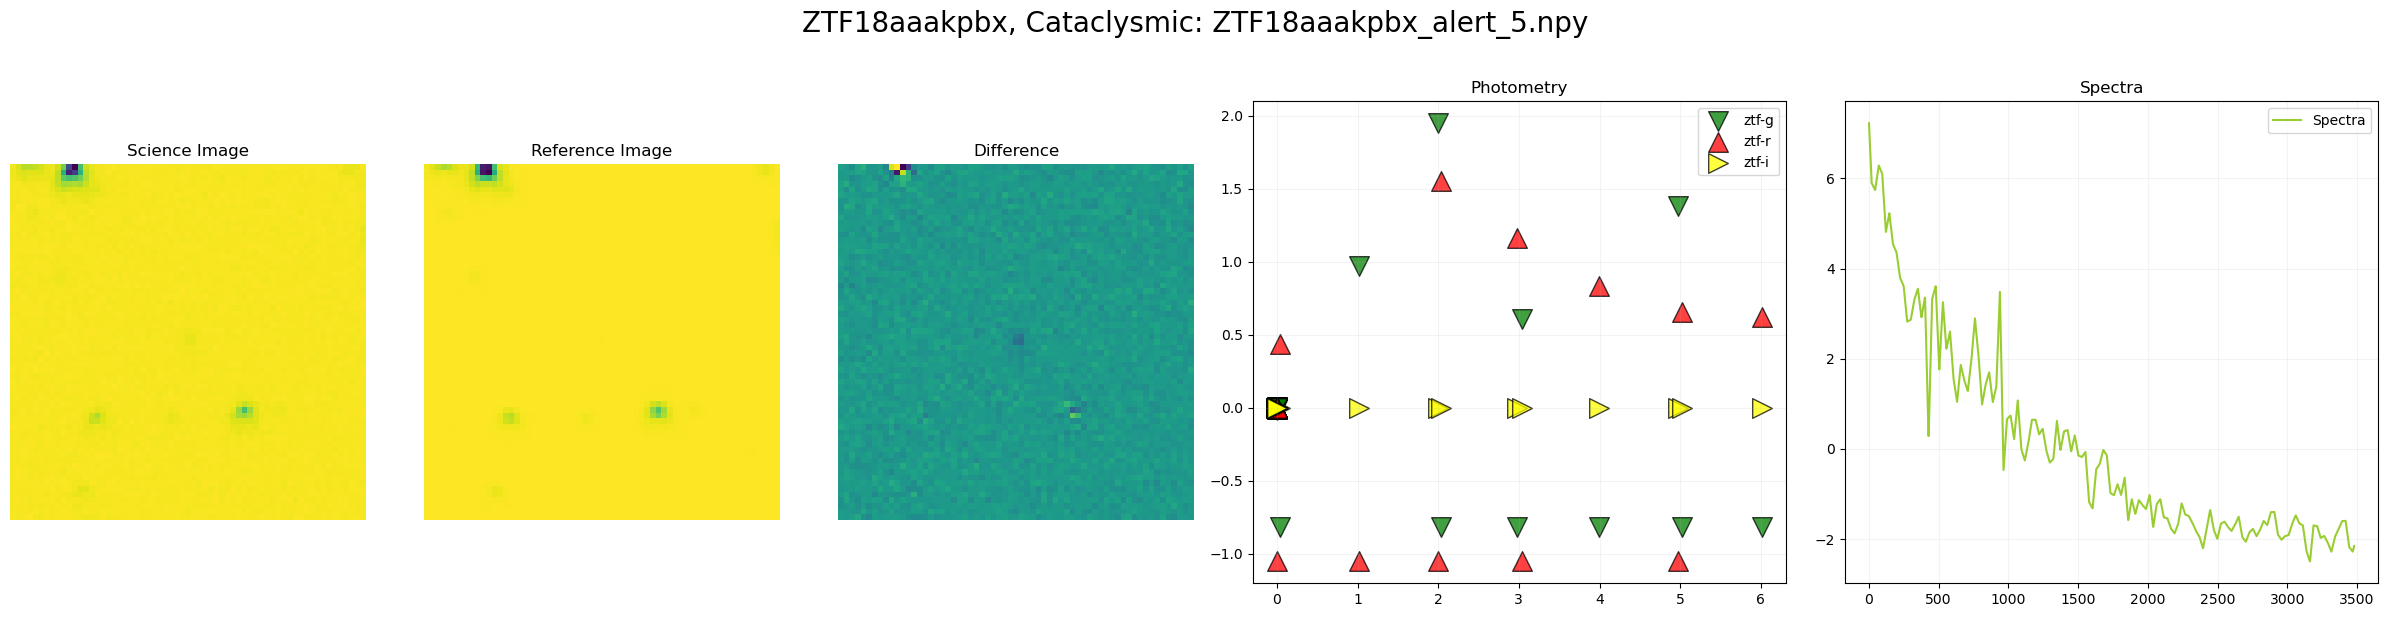

ZTF18aaakpbx: ZTF18aaakpbx_alert_6.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0423,  0.1171, -0.9988,  0.1648, -1.1137,  1.2644, -0.0173, -0.0271,
        -0.5750,  0.1731])


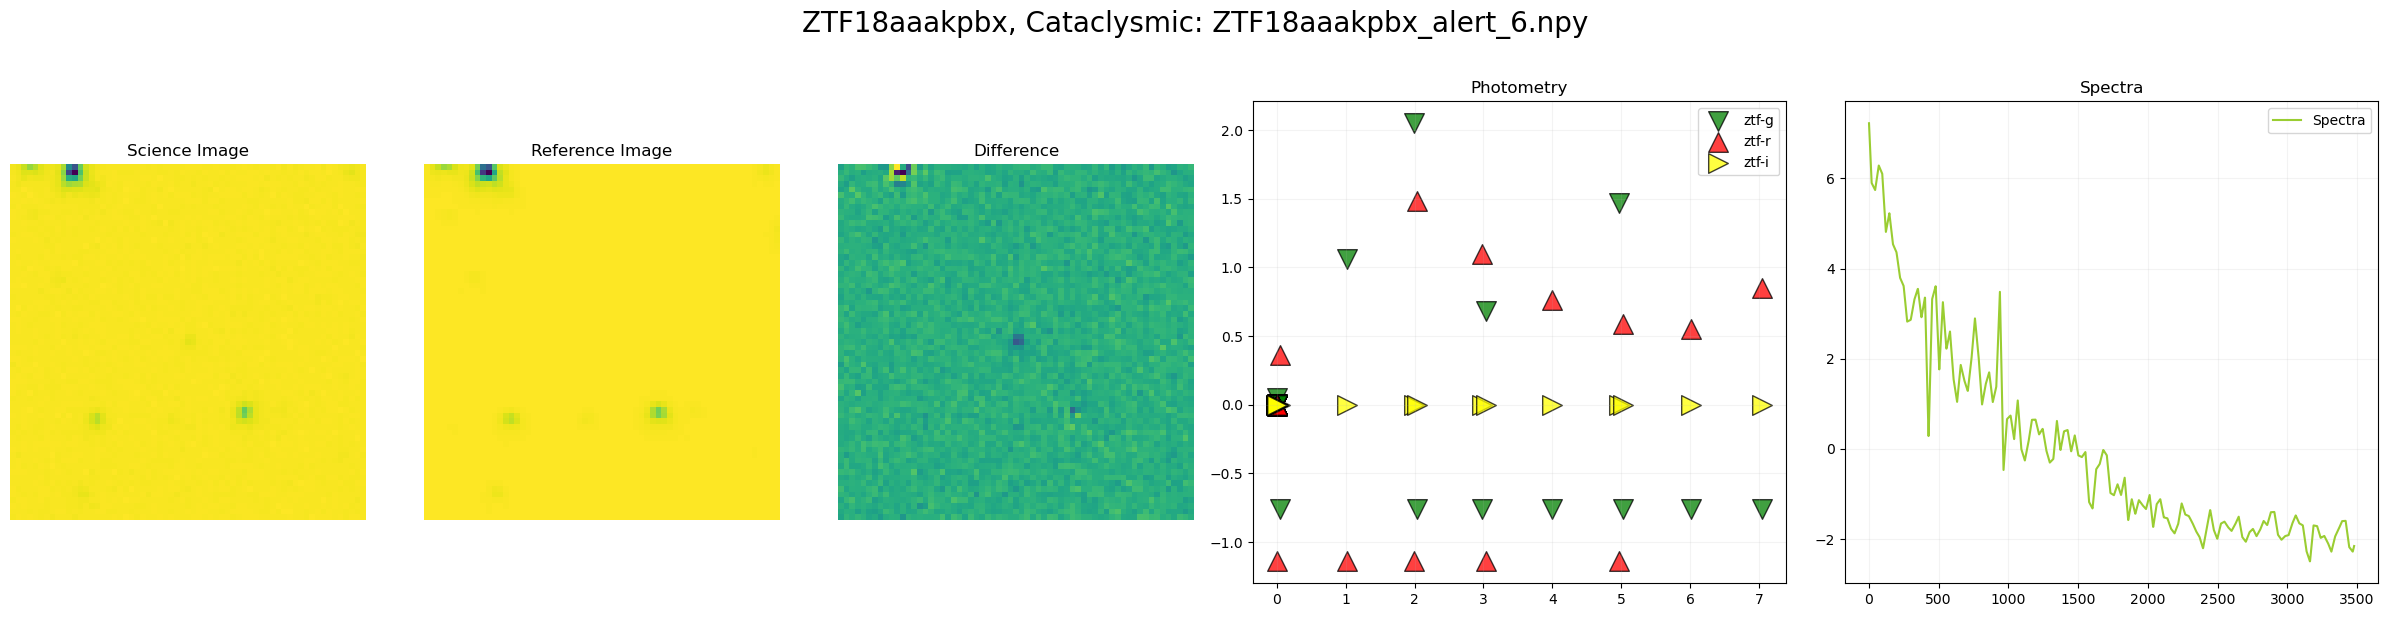

ZTF18aaakpbx: ZTF18aaakpbx_alert_7.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8231,  0.1136, -1.0549,  1.0890,  0.1372, -0.0125,
         1.1850,  0.4705])


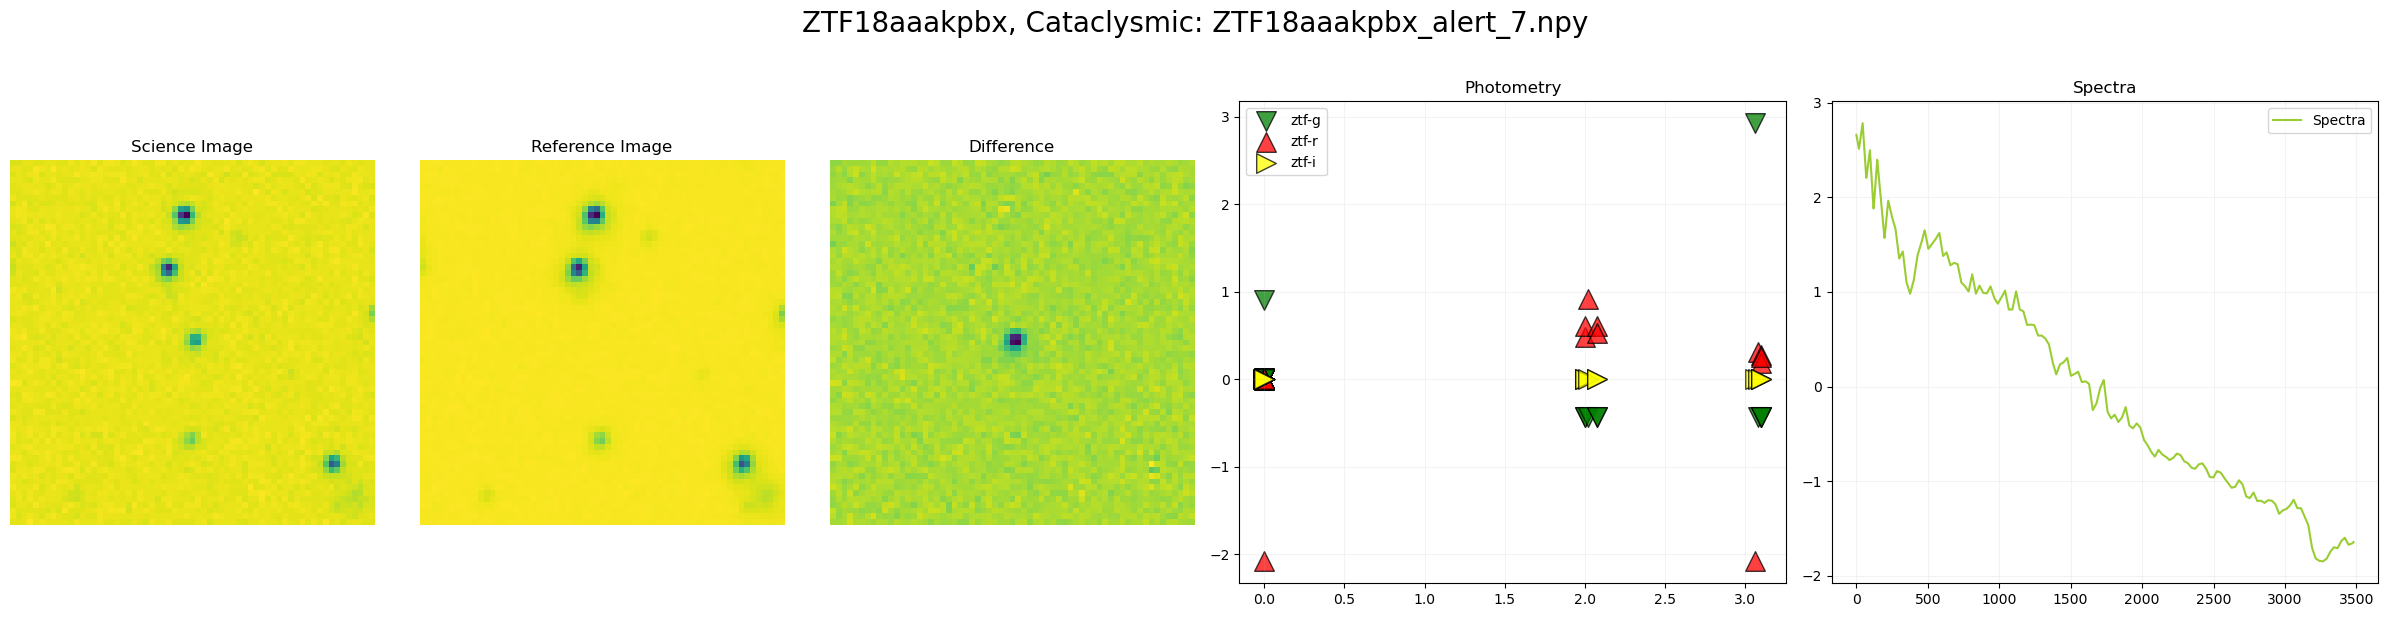

ZTF18aabfxpw: ZTF18aabfxpw_alert_10.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.7720,  0.1115, -1.0549,  1.0890,  0.1372, -0.0310,
        -0.8140, -7.4944])


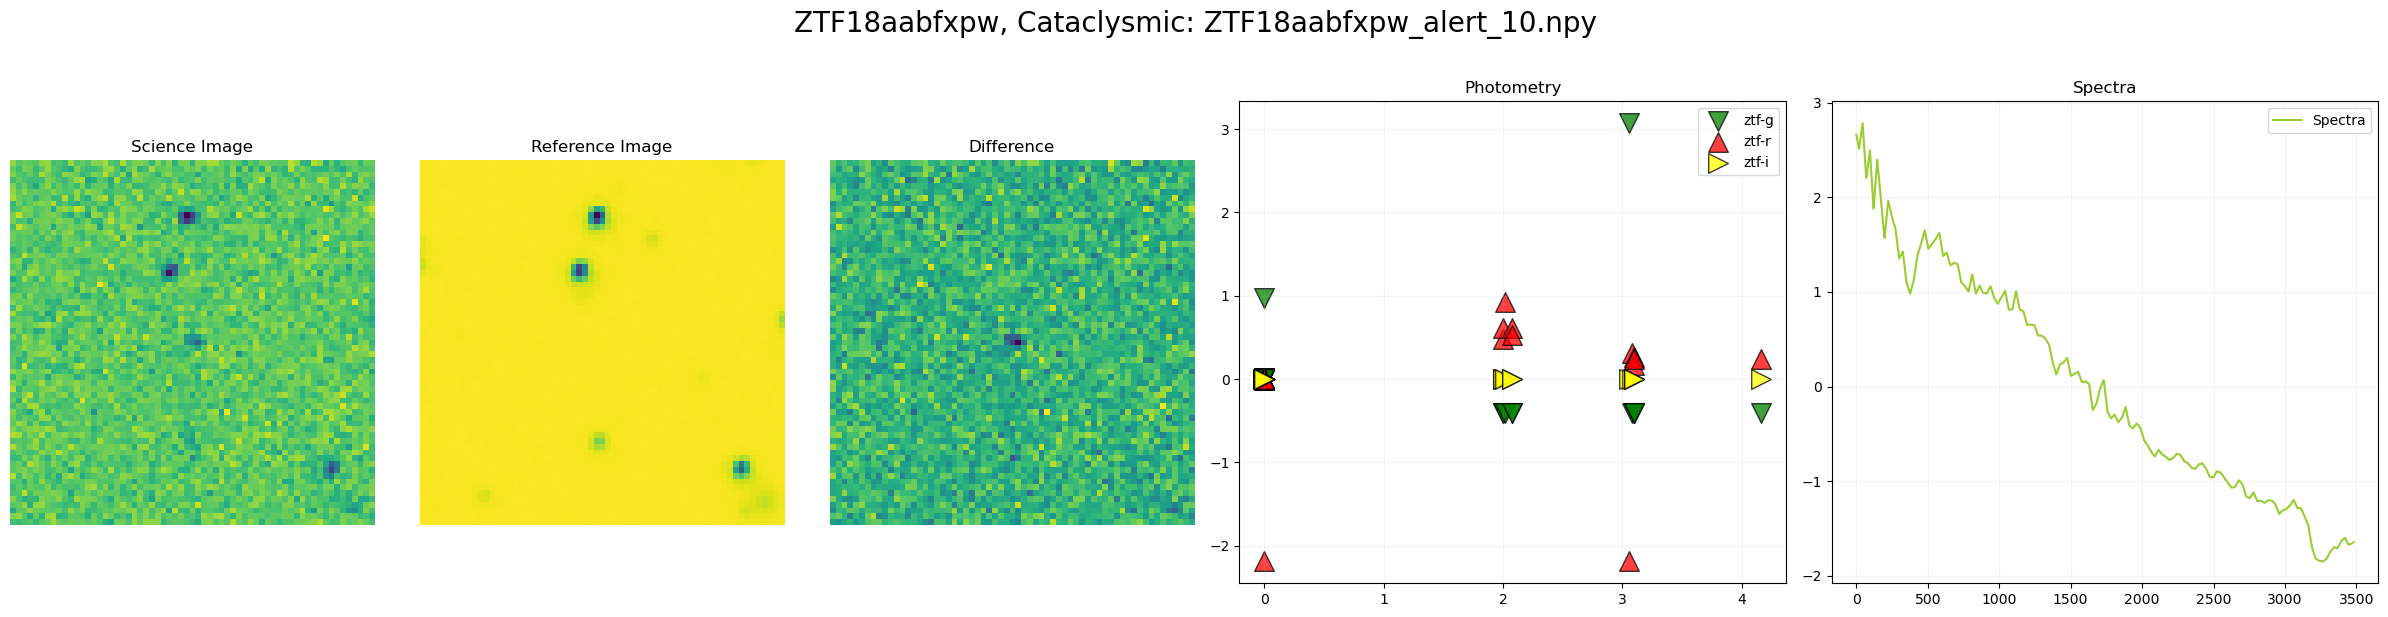

ZTF18aabfxpw: ZTF18aabfxpw_alert_11.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8774,  0.1174, -1.0549,  1.0890,  0.1372, -0.0491,
        -0.4529,  0.2197])


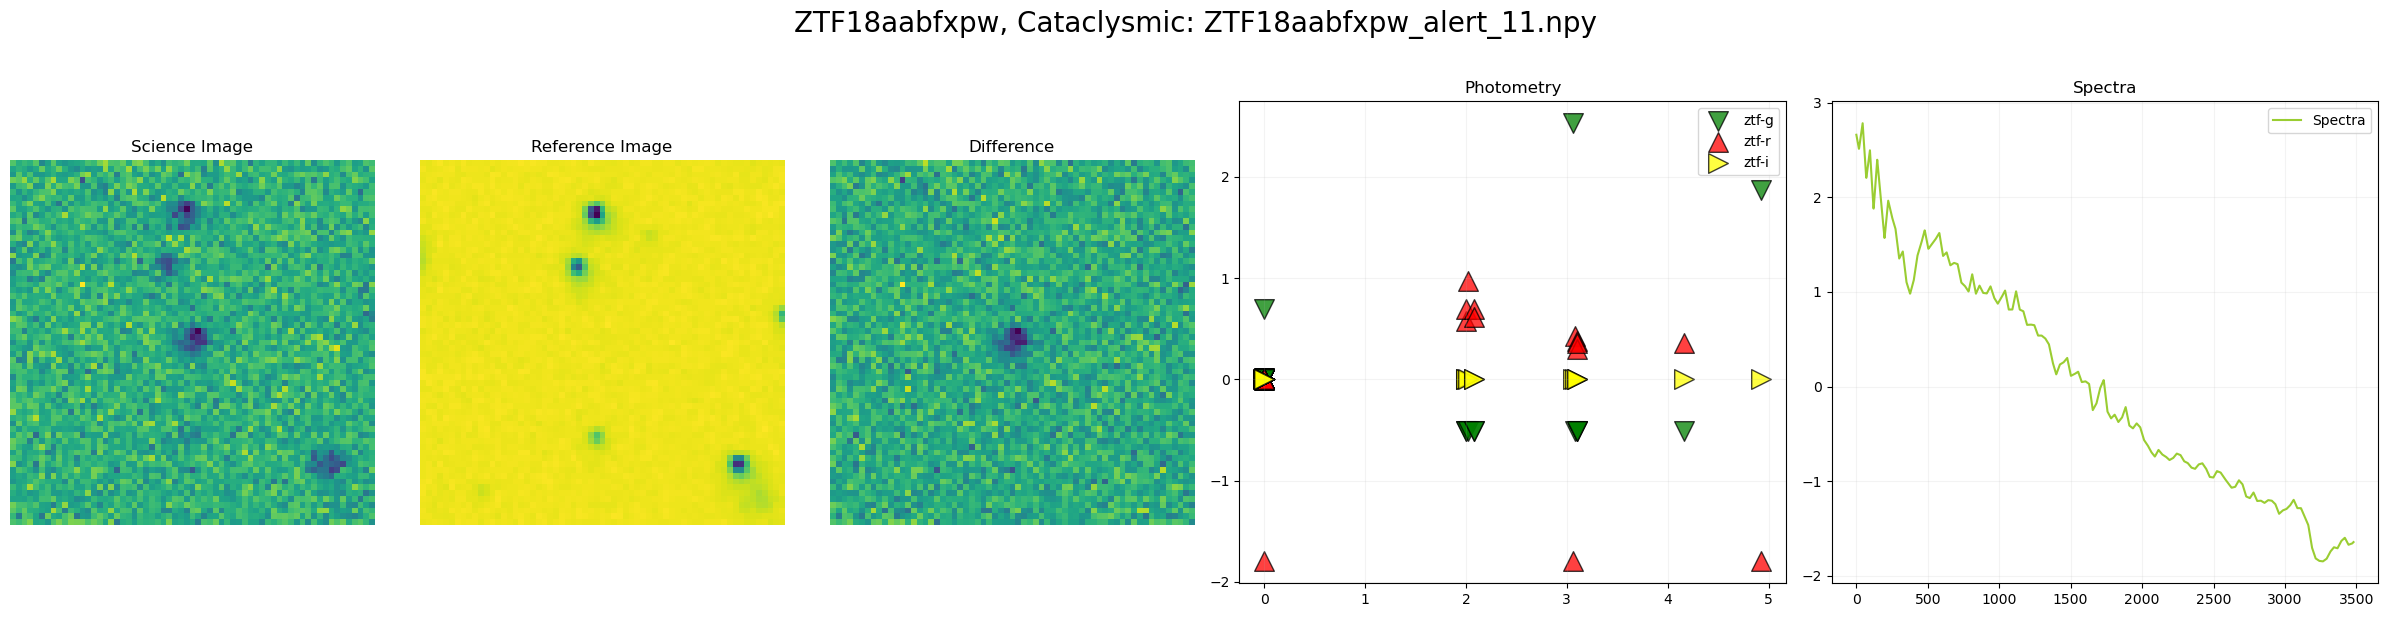

ZTF18aabfxpw: ZTF18aabfxpw_alert_12.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8296,  0.1134, -1.0549,  1.0890,  0.1372, -0.0310,
         0.1998, -0.7434])


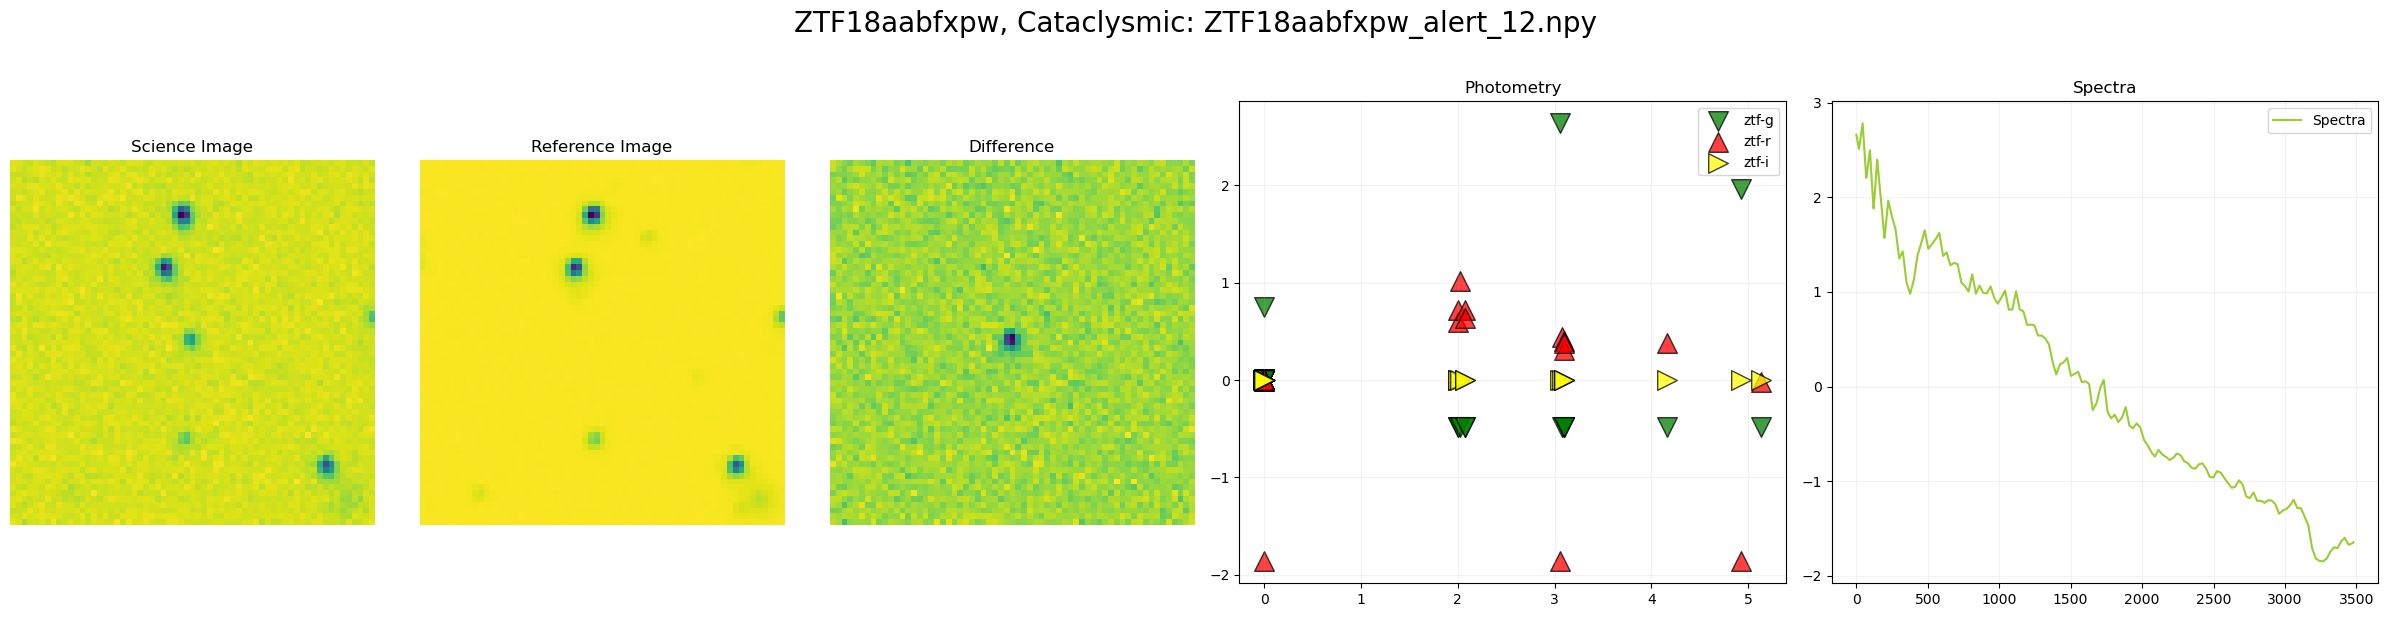

ZTF18aabfxpw: ZTF18aabfxpw_alert_13.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8081,  0.1130, -1.0549,  1.0890,  0.1372, -0.0143,
         0.1560,  0.5410])


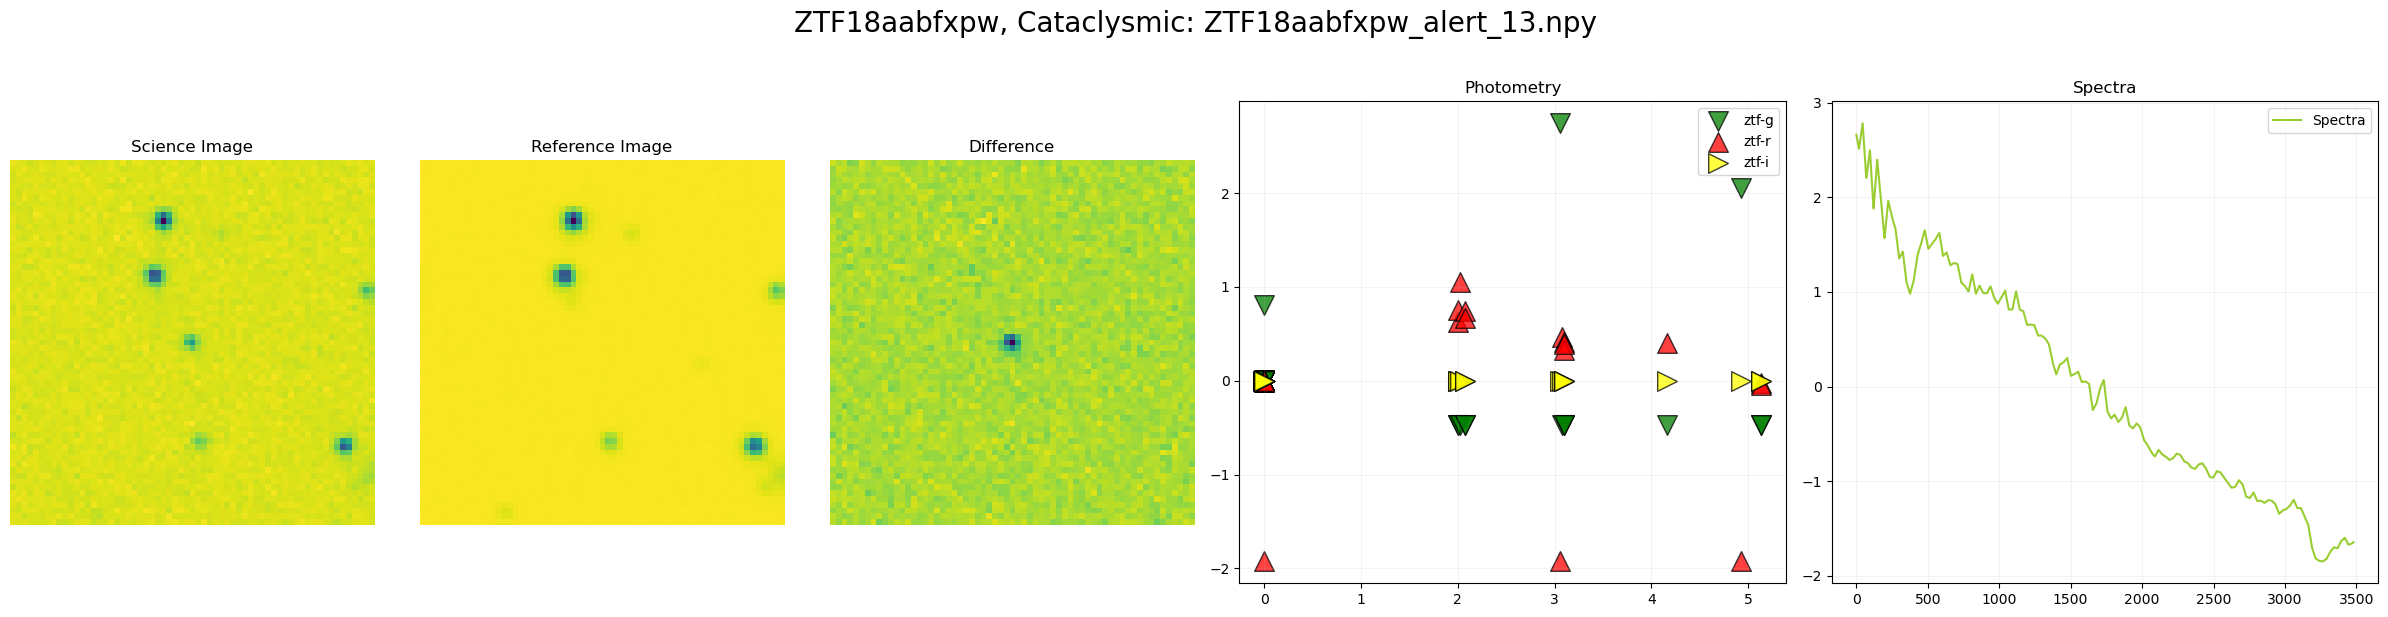

ZTF18aabfxpw: ZTF18aabfxpw_alert_14.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8286,  0.1133, -1.0549,  1.0890,  0.1372, -0.0310,
         0.5145,  0.7323])


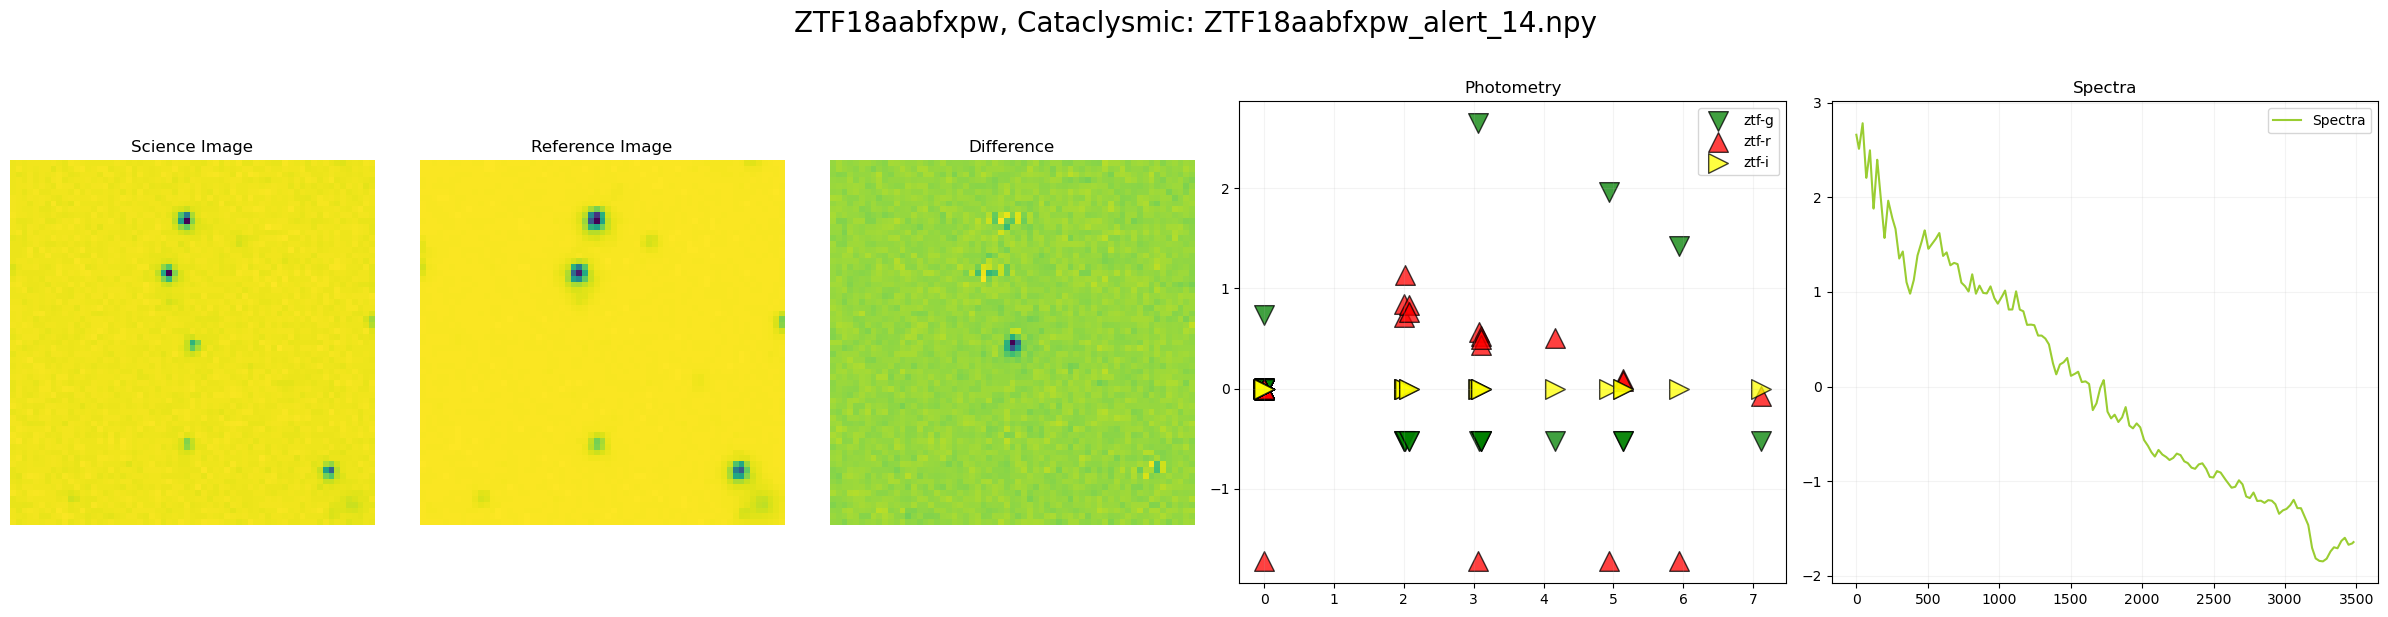

ZTF18aabfxpw: ZTF18aabfxpw_alert_15.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8374,  0.1137, -1.0549,  1.0890,  0.1372, -0.0143,
         0.4042,  0.9048])


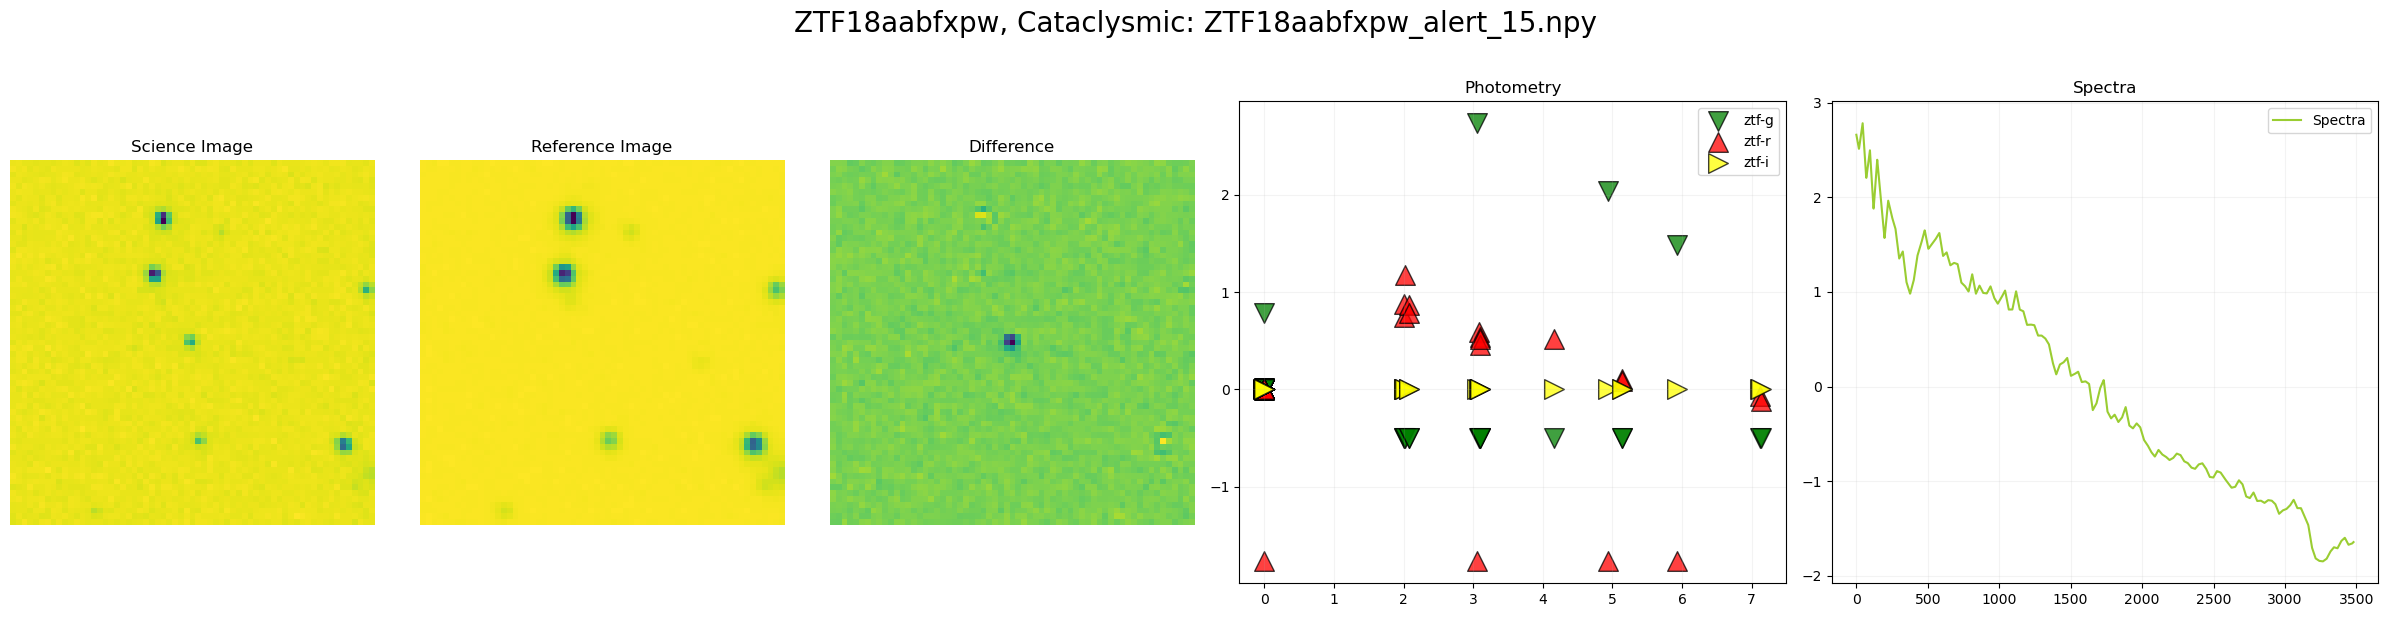

ZTF18aabfxpw: ZTF18aabfxpw_alert_16.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8247,  0.1131, -1.0549,  1.0890,  0.1372, -0.0170,
         0.3017,  0.7749])


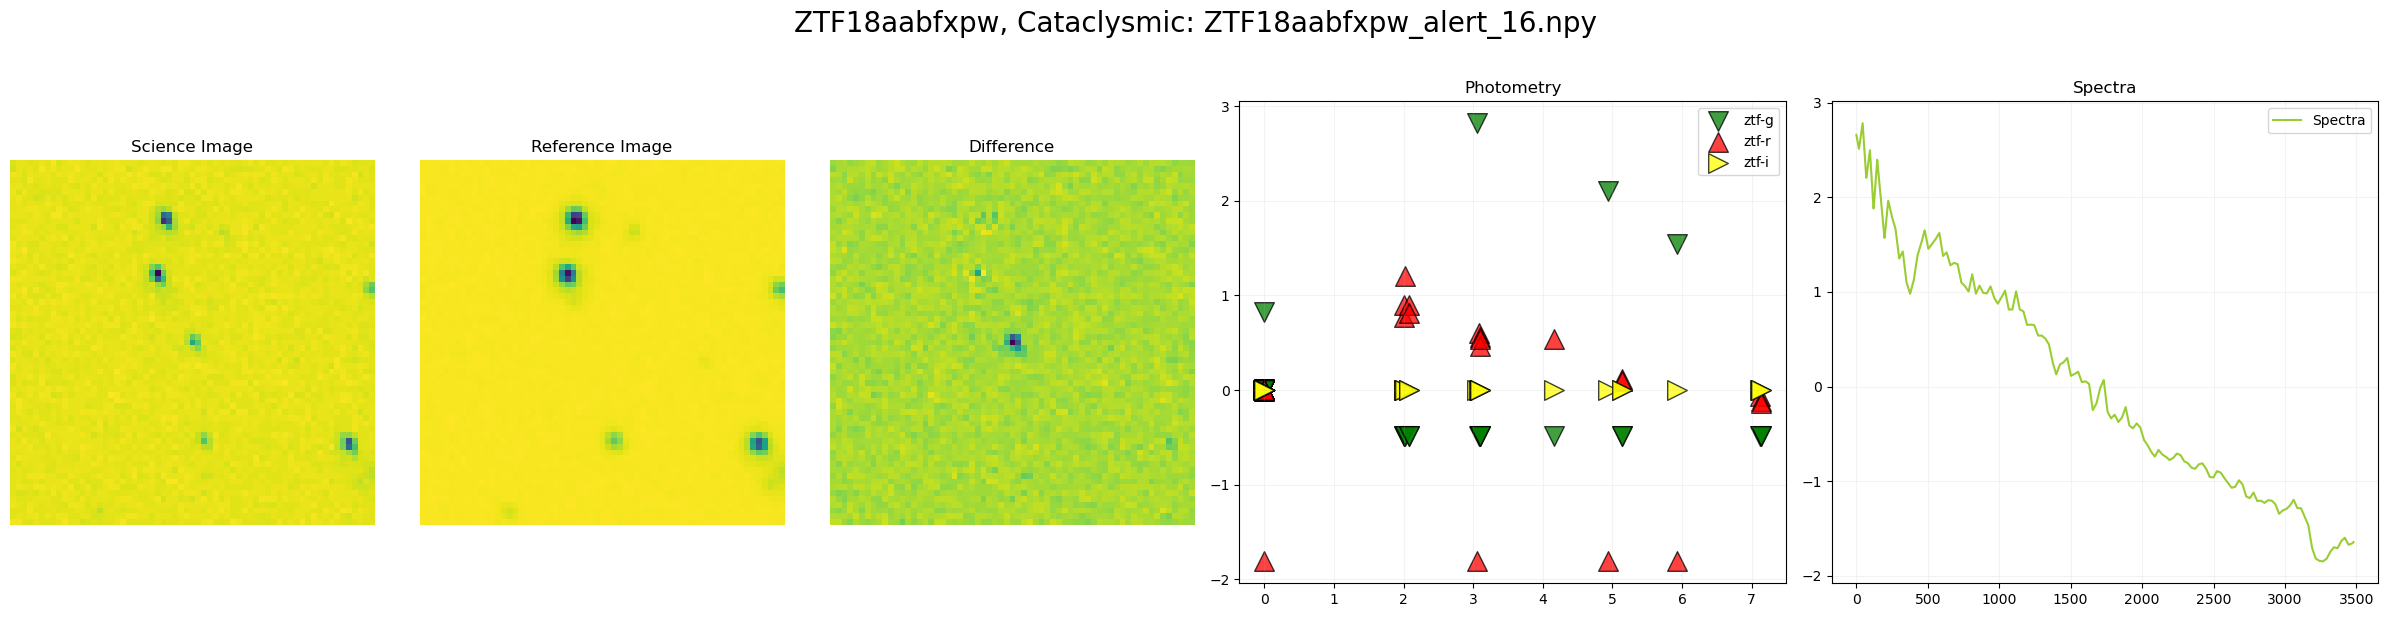

ZTF18aabfxpw: ZTF18aabfxpw_alert_17.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8284,  0.1135, -1.0549,  1.0890,  0.1372, -0.0125,
         0.4611,  1.4743])


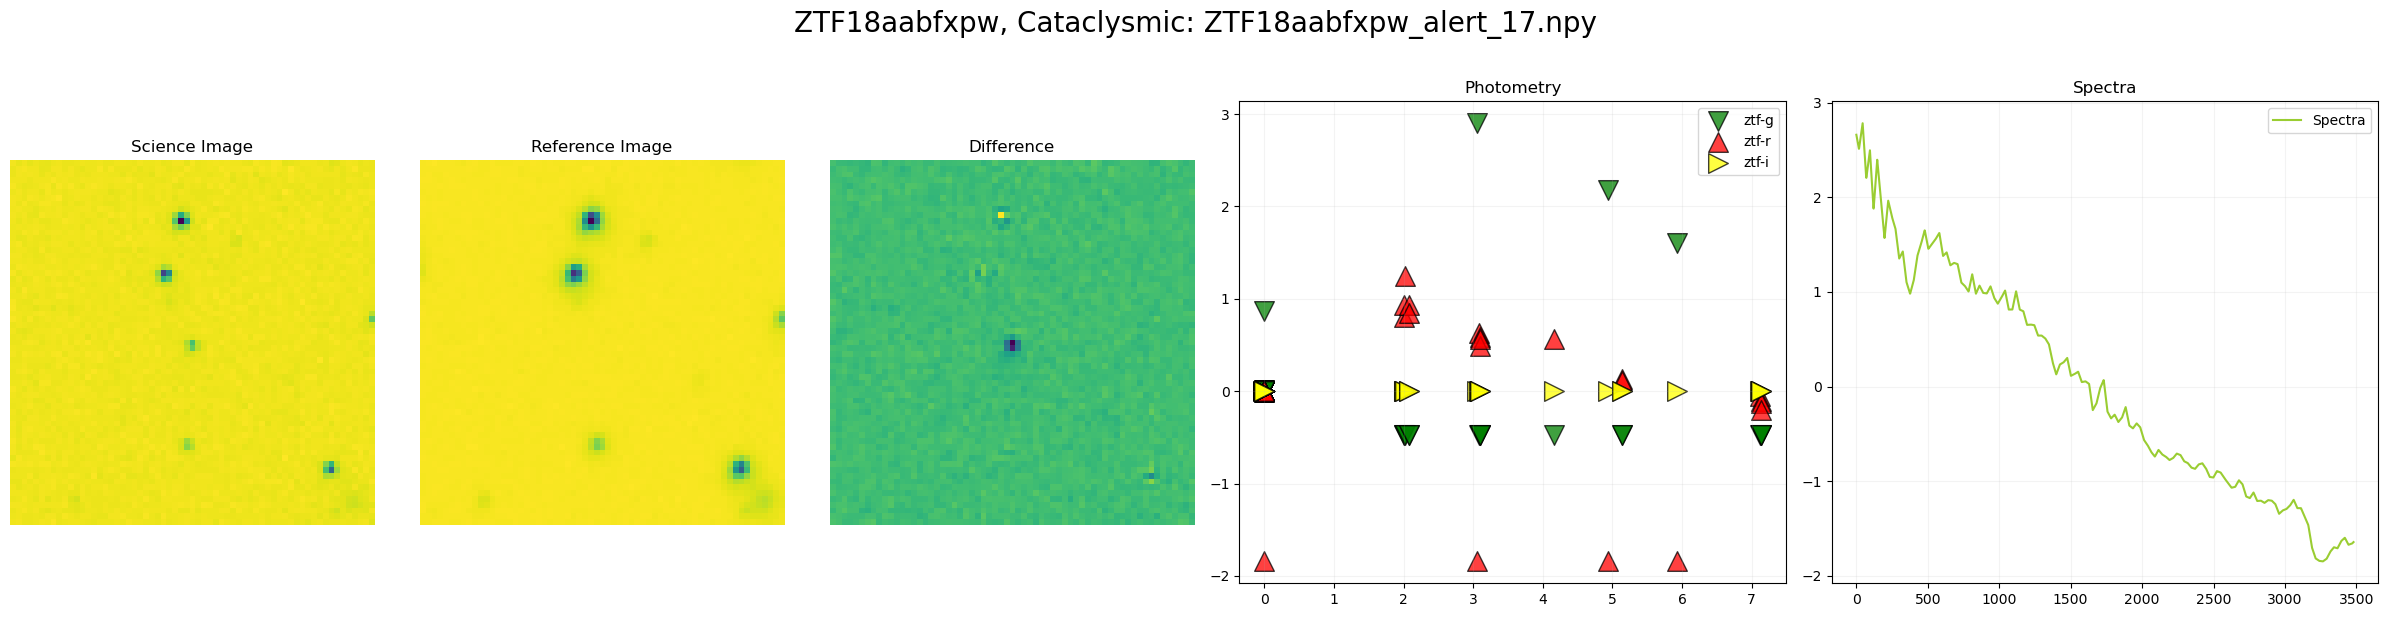

ZTF18aabfxpw: ZTF18aabfxpw_alert_18.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0496,  0.1163, -0.8312,  0.1137, -1.0549,  1.0890,  0.1372, -0.0170,
         0.3991, -0.6271])


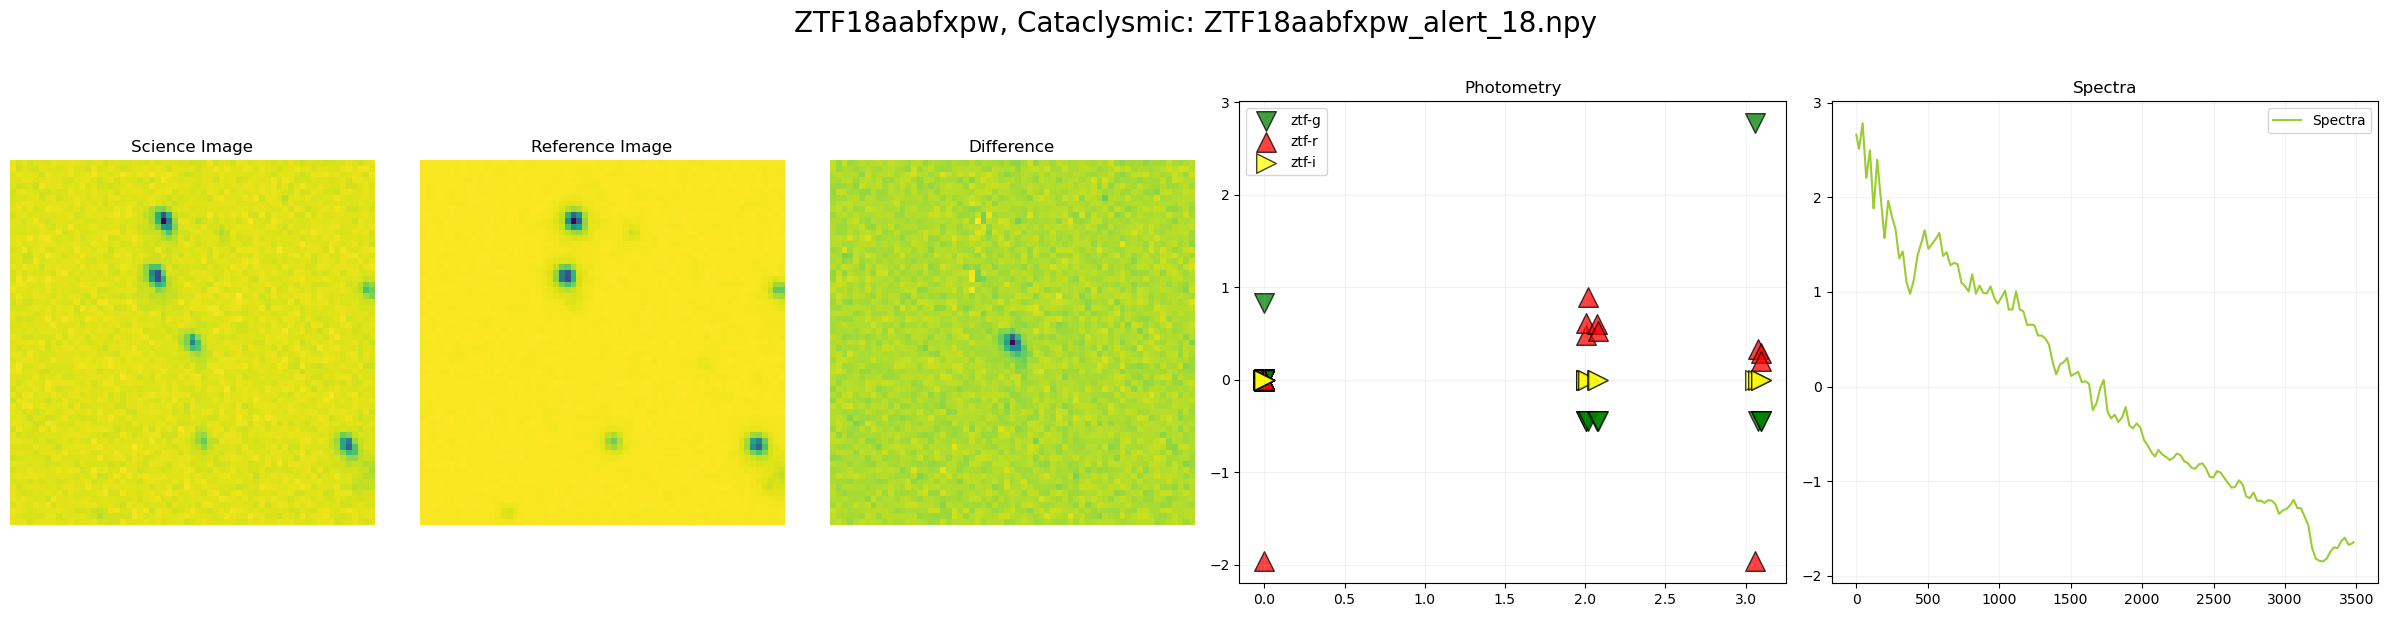

ZTF18aabfxpw: ZTF18aabfxpw_alert_9.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2115,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0266,  -0.5794,  -1.4654])


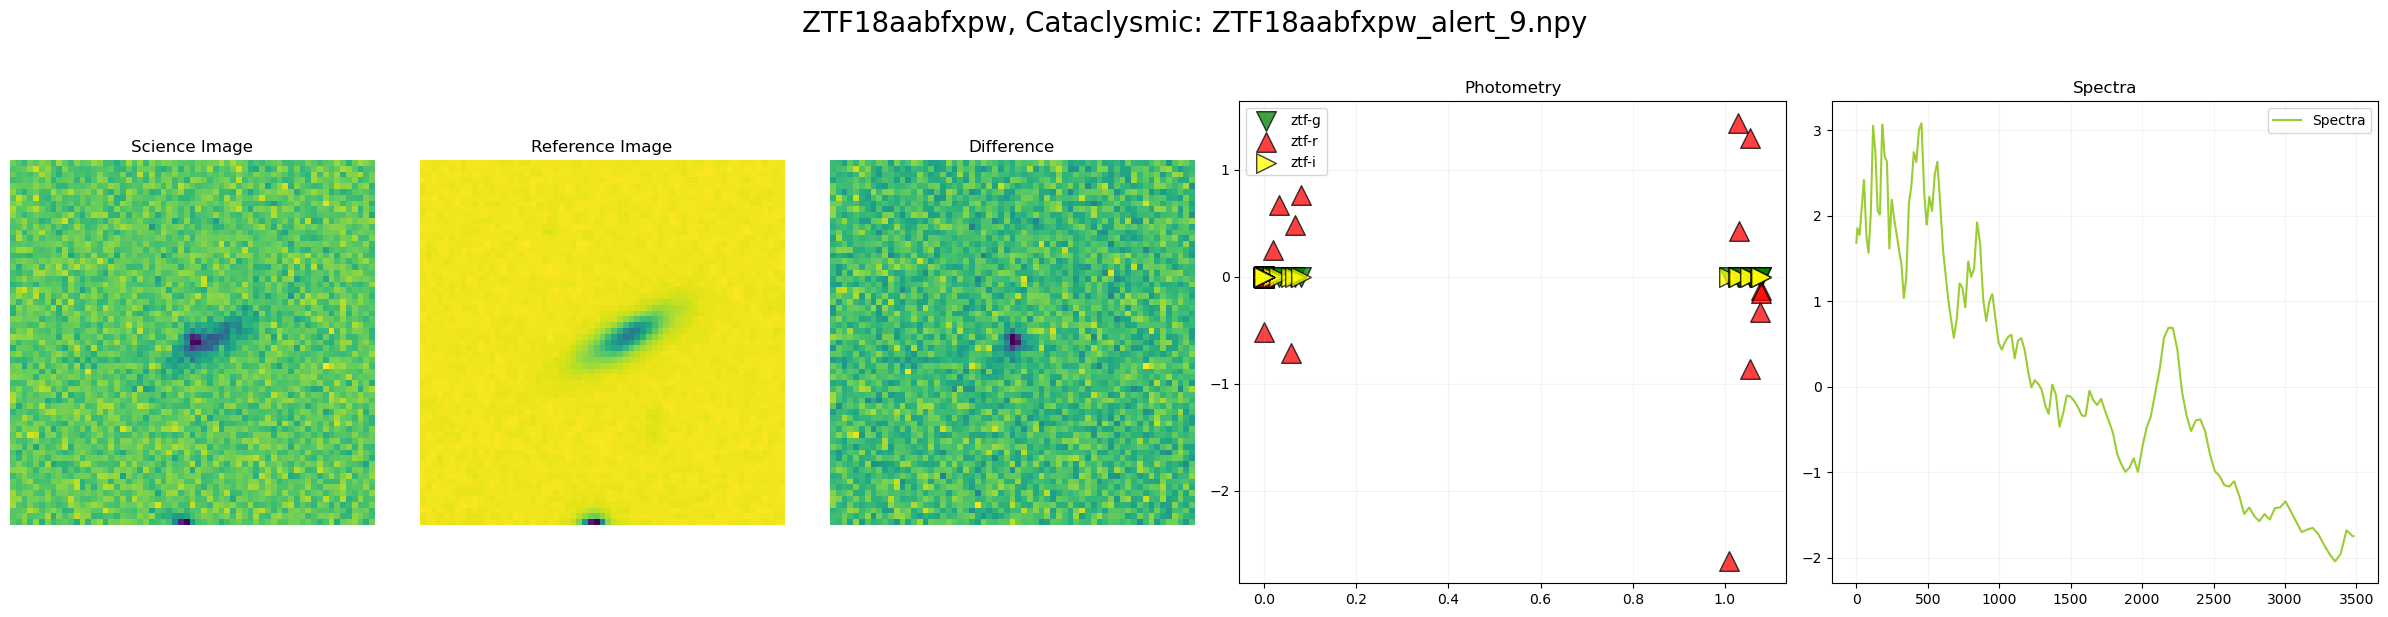

ZTF18aabssth: ZTF18aabssth_alert_13.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2264,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0287,  -0.0387,   0.4947])


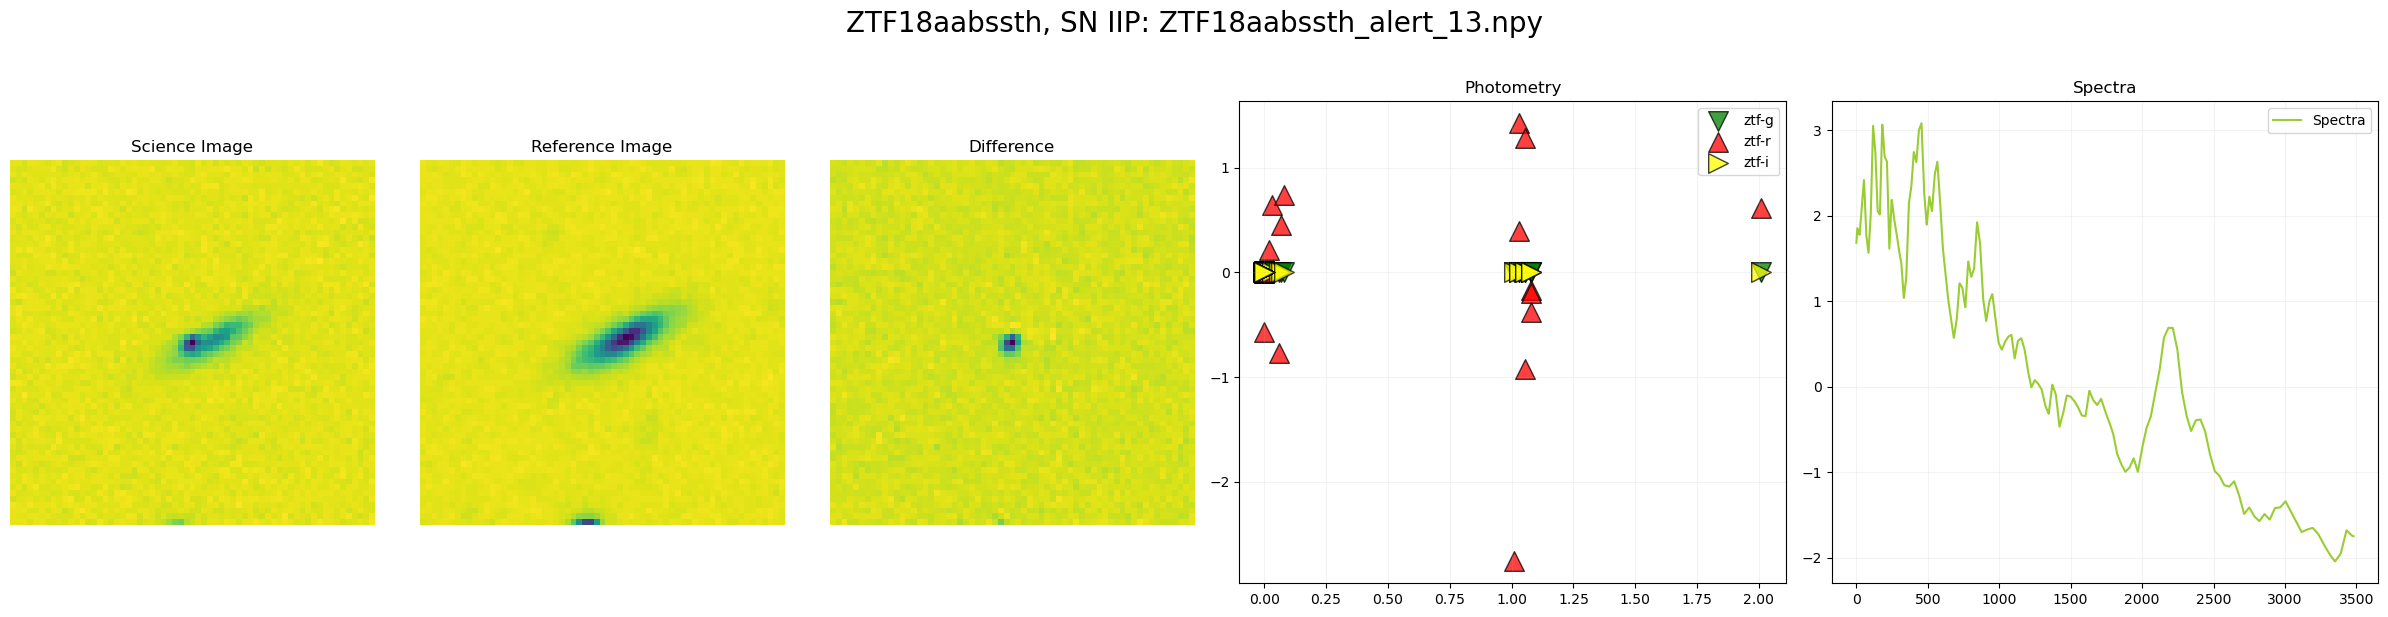

ZTF18aabssth: ZTF18aabssth_alert_14.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2157,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0266,   0.0616,  -0.5439])


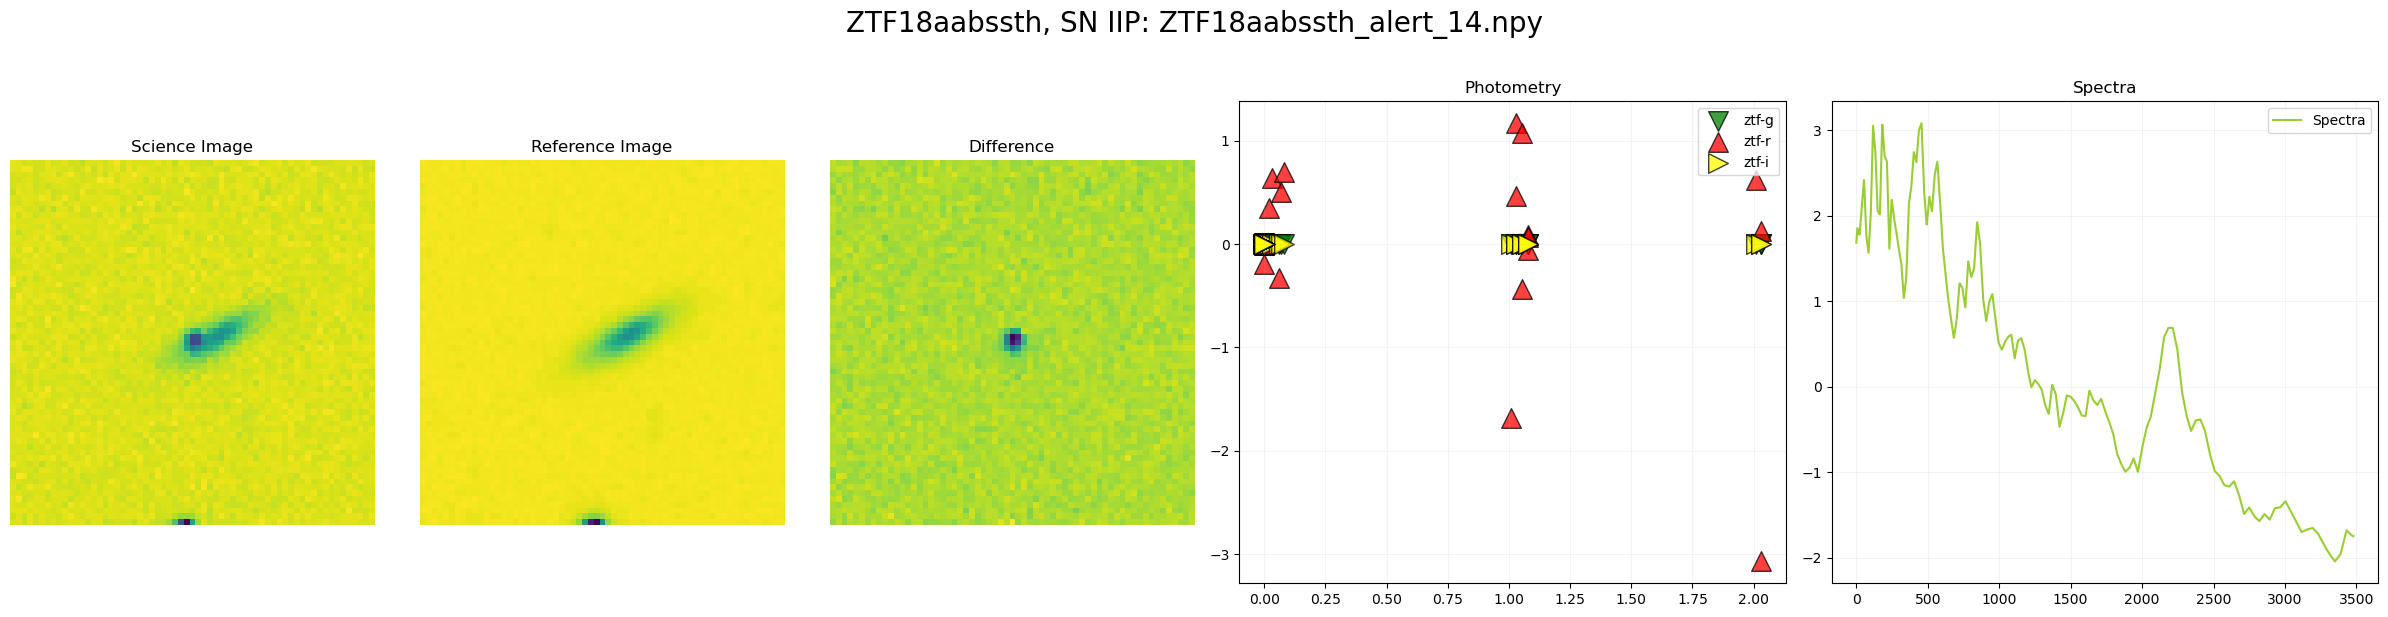

ZTF18aabssth: ZTF18aabssth_alert_16.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2158,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0287,   0.4733,   0.2953])


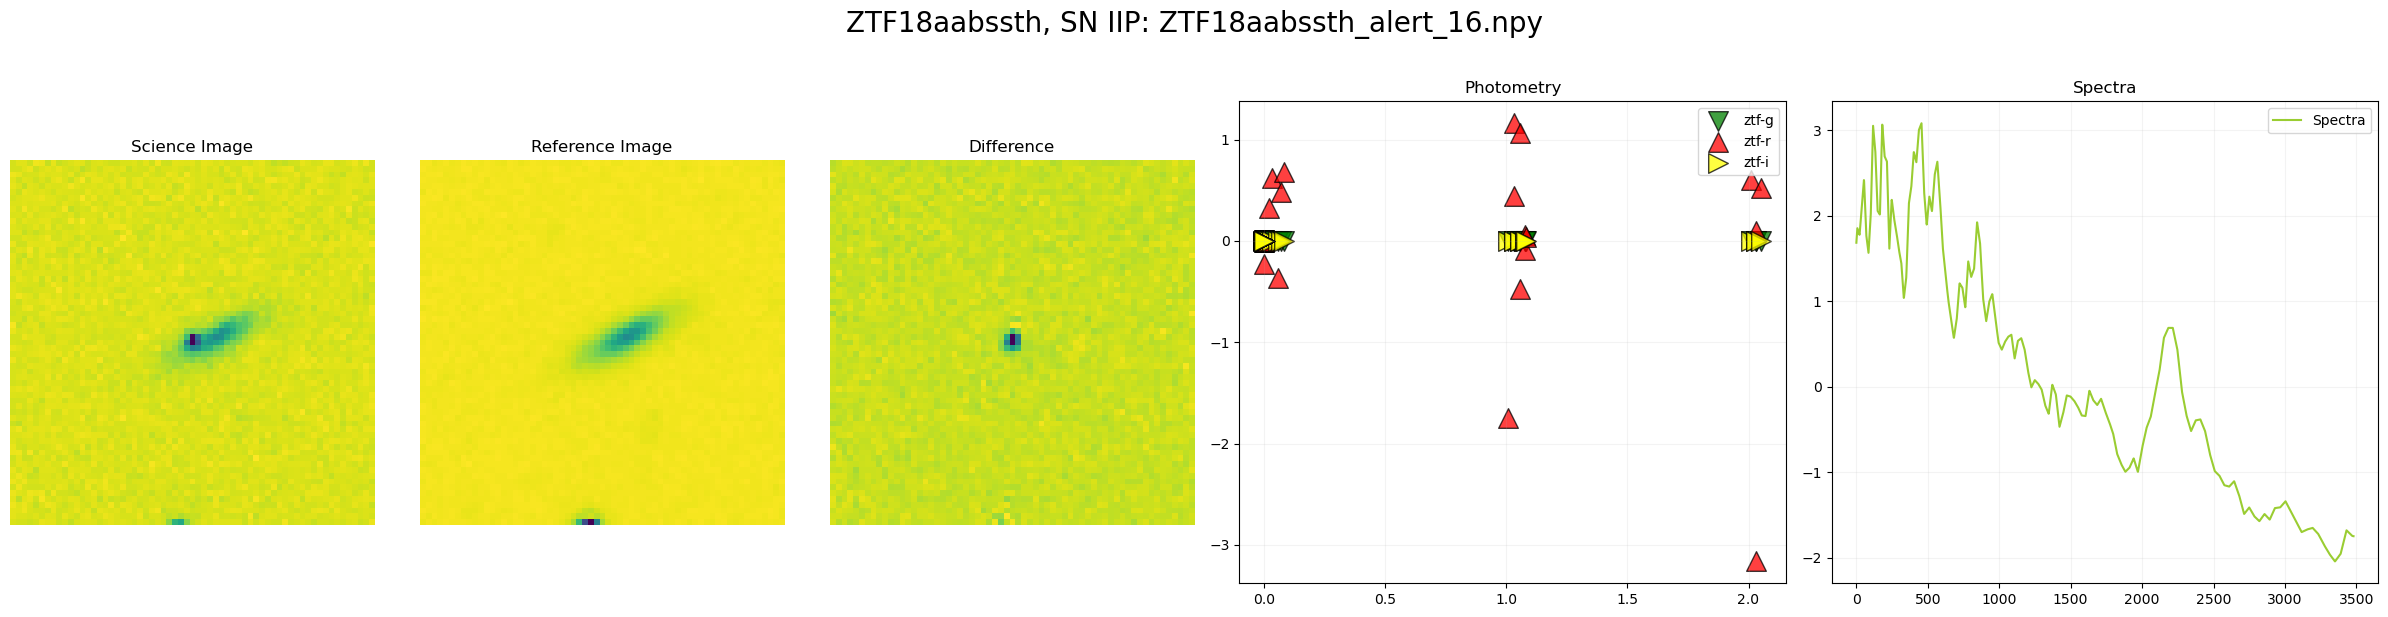

ZTF18aabssth: ZTF18aabssth_alert_17.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2076,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0287,   0.8238,   0.1843])


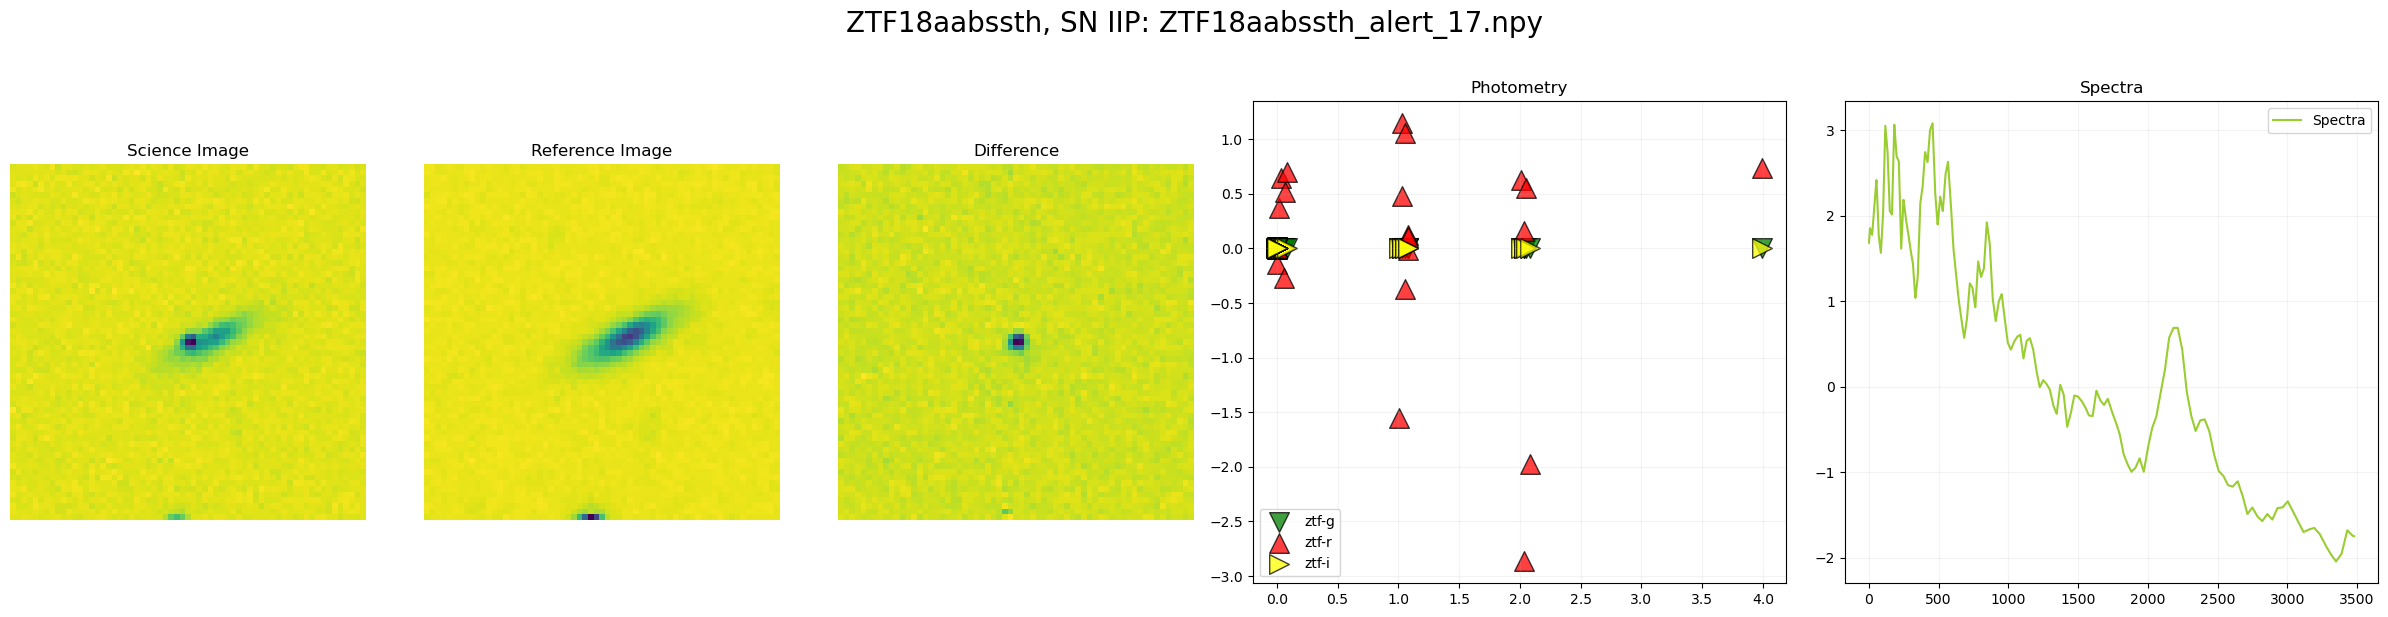

ZTF18aabssth: ZTF18aabssth_alert_19.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2166,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0266,   0.4205,   0.1116])


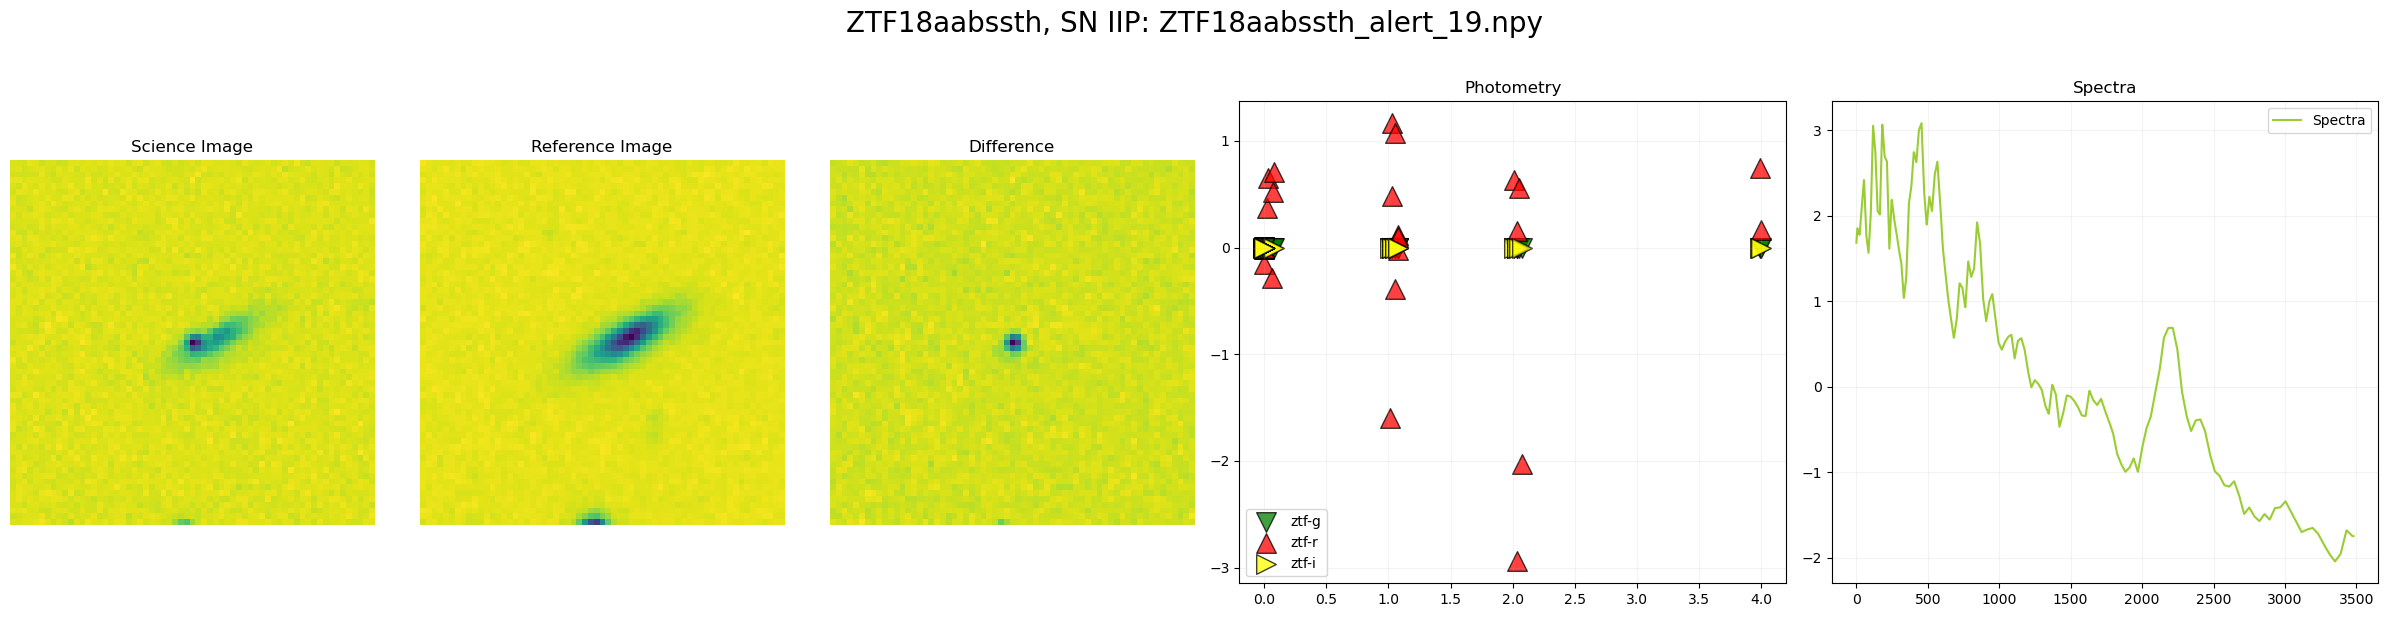

ZTF18aabssth: ZTF18aabssth_alert_20.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2213,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0287,   0.8912,   0.3247])


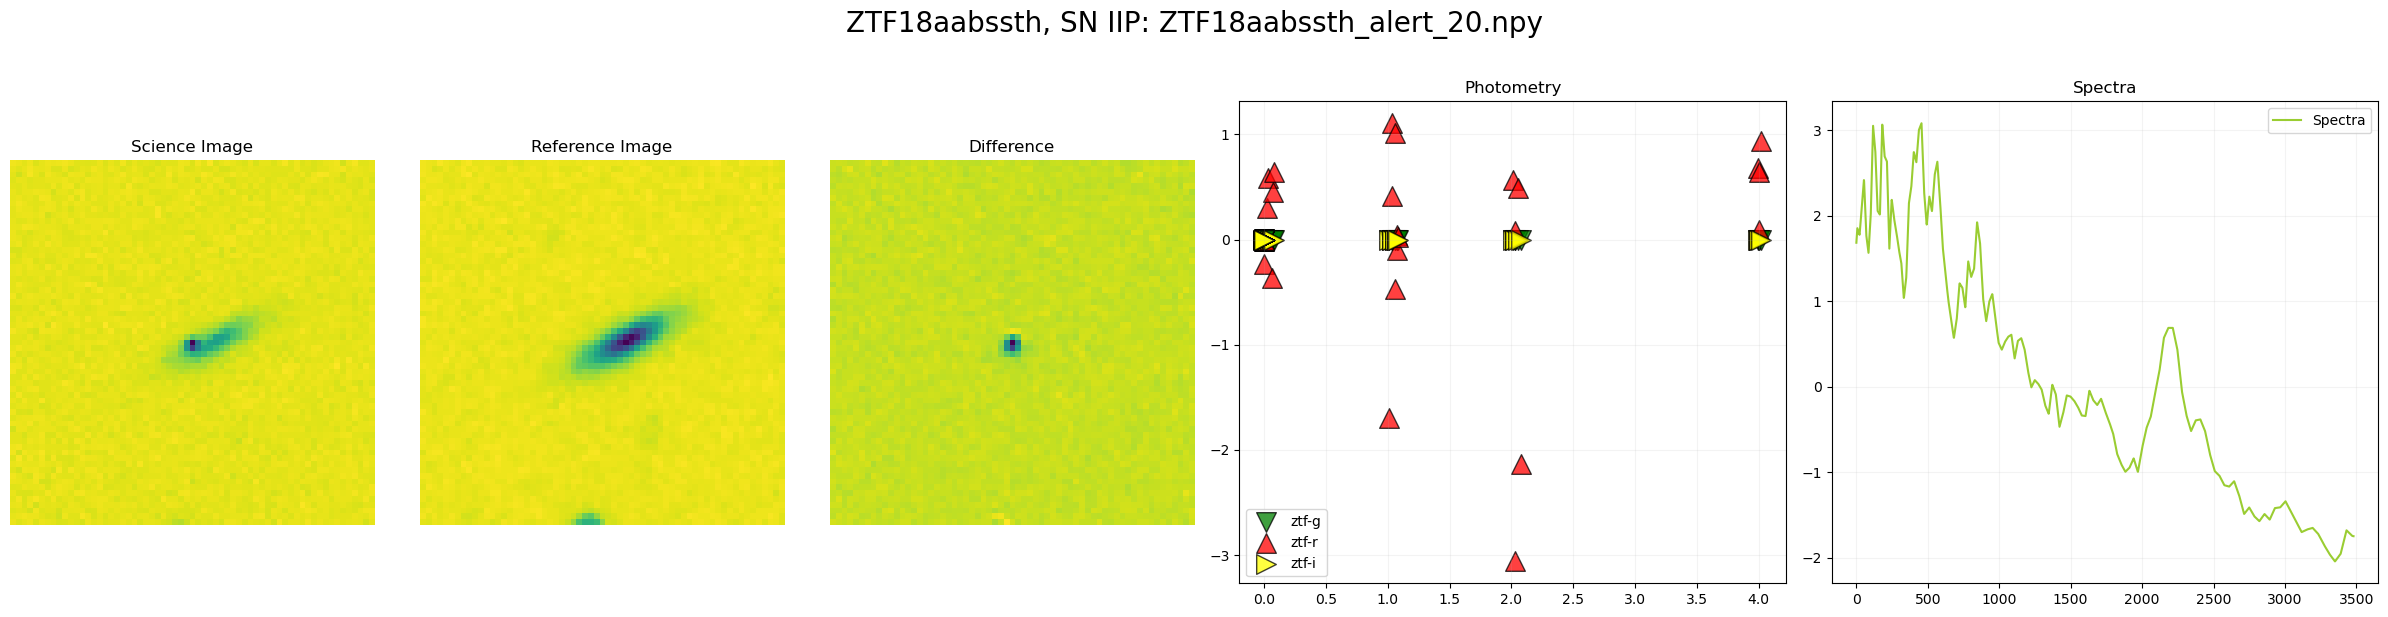

ZTF18aabssth: ZTF18aabssth_alert_22.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2151,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0266,   0.4552,  -0.3604])


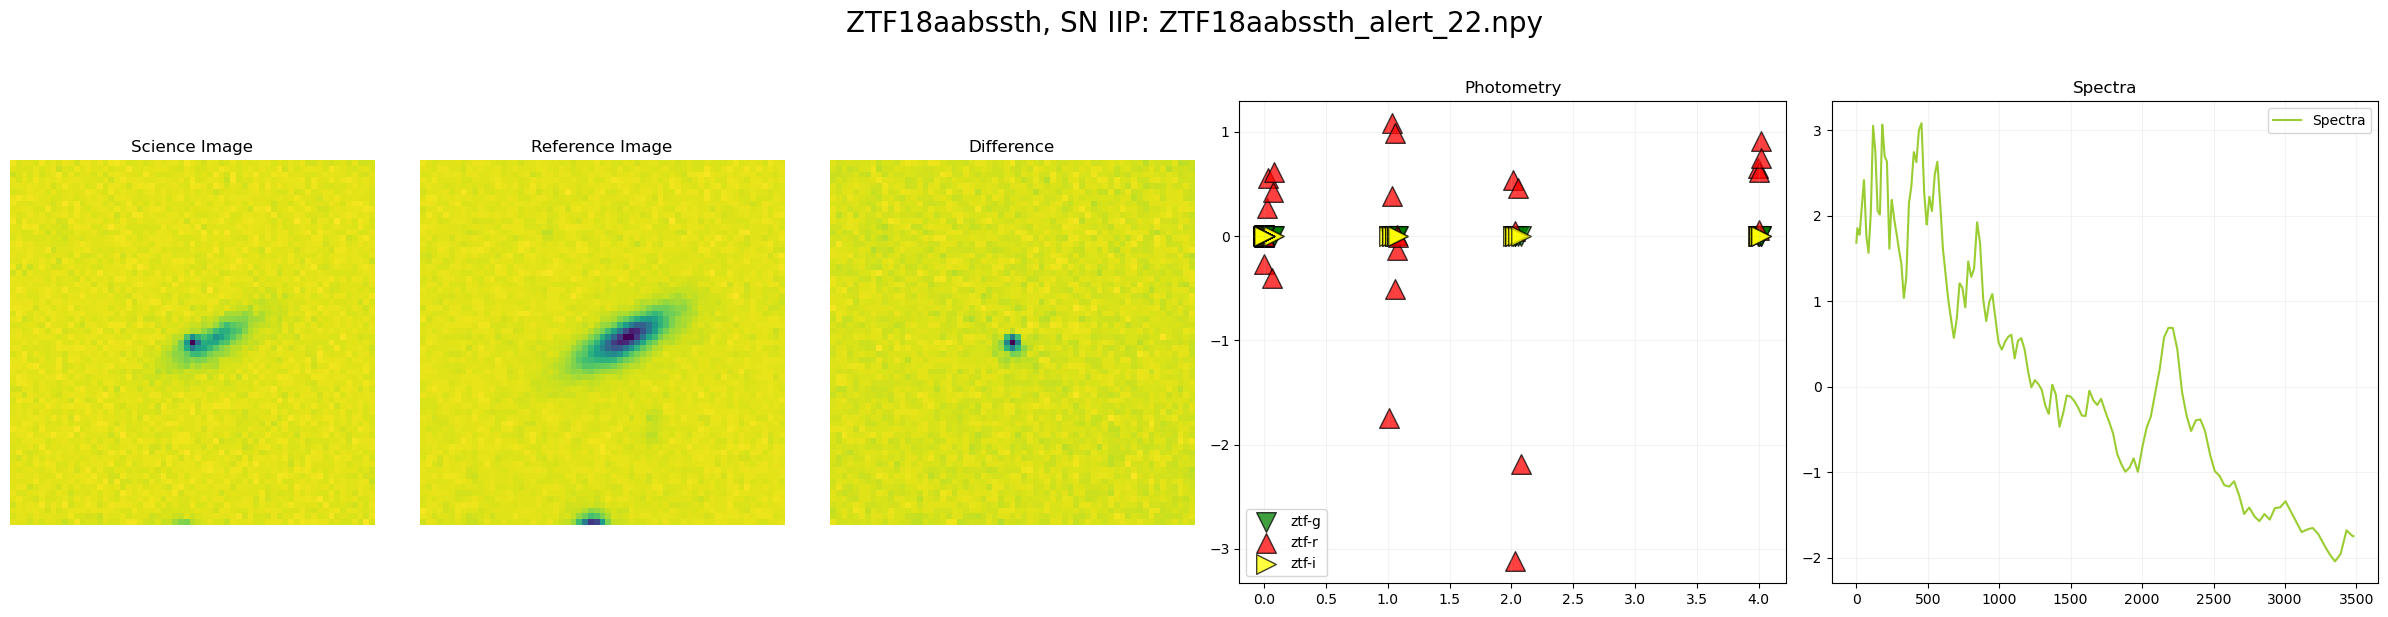

ZTF18aabssth: ZTF18aabssth_alert_23.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.2002,  -8.9276,  -0.2010,  -0.1721, -22.2515,
          0.0287,   0.9693,   0.2217])


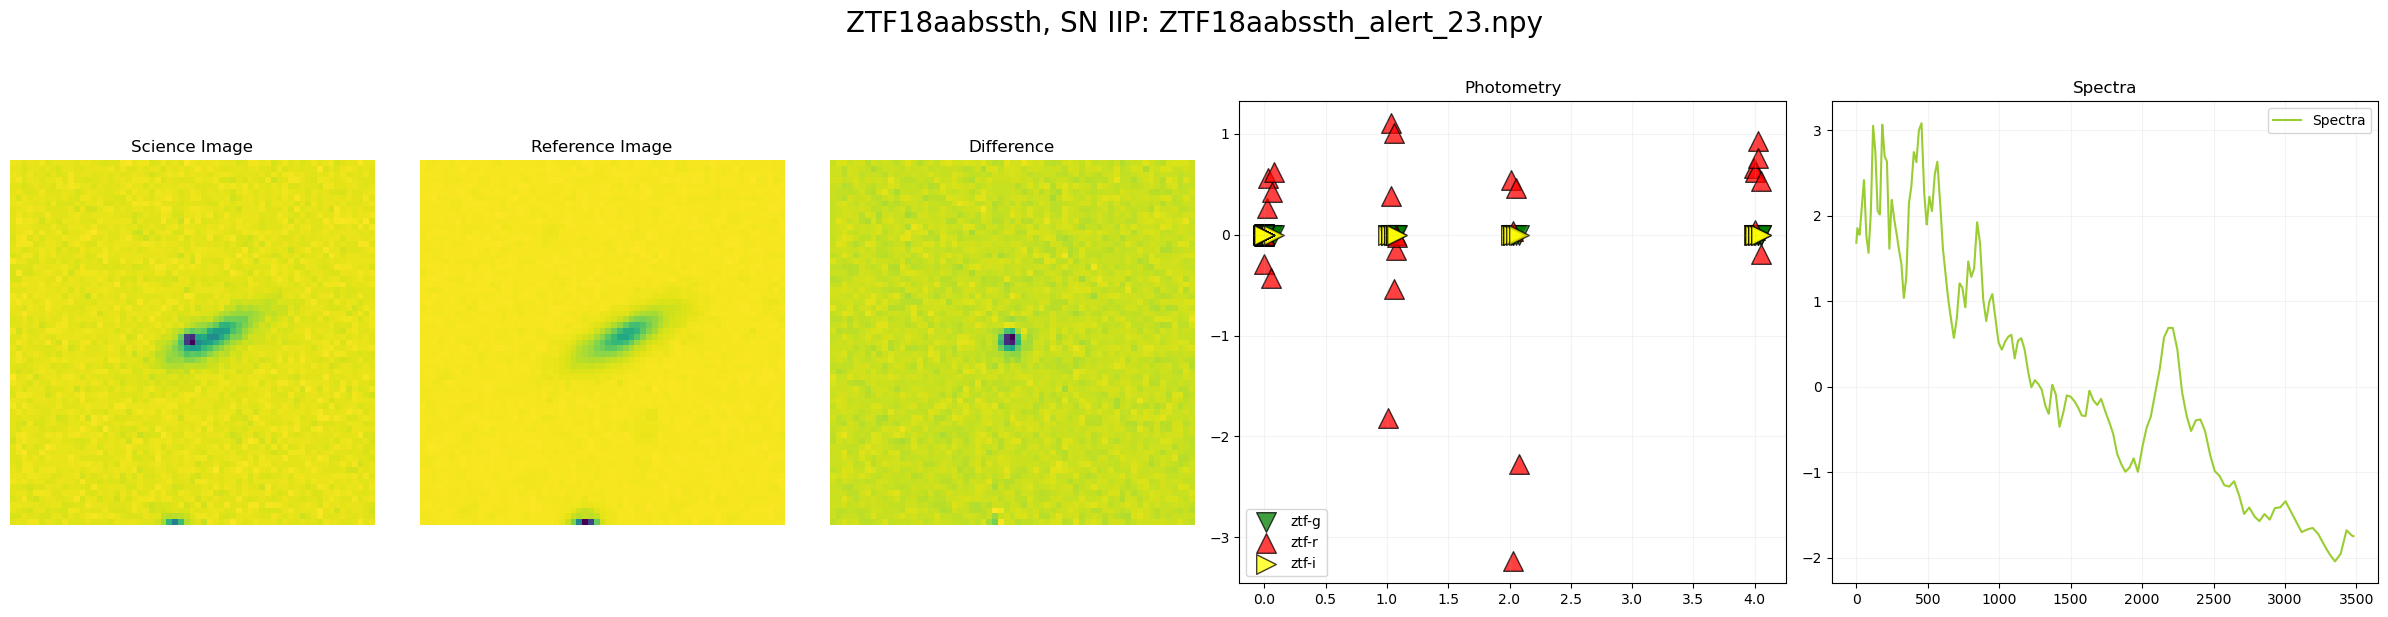

ZTF18aabssth: ZTF18aabssth_alert_25.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-2.2733e+01, -8.9390e+00,  2.2595e-01, -8.9276e+00, -2.0099e-01,
        -1.7212e-01, -2.2252e+01,  2.6591e-02, -1.9961e-01,  4.3823e-03])


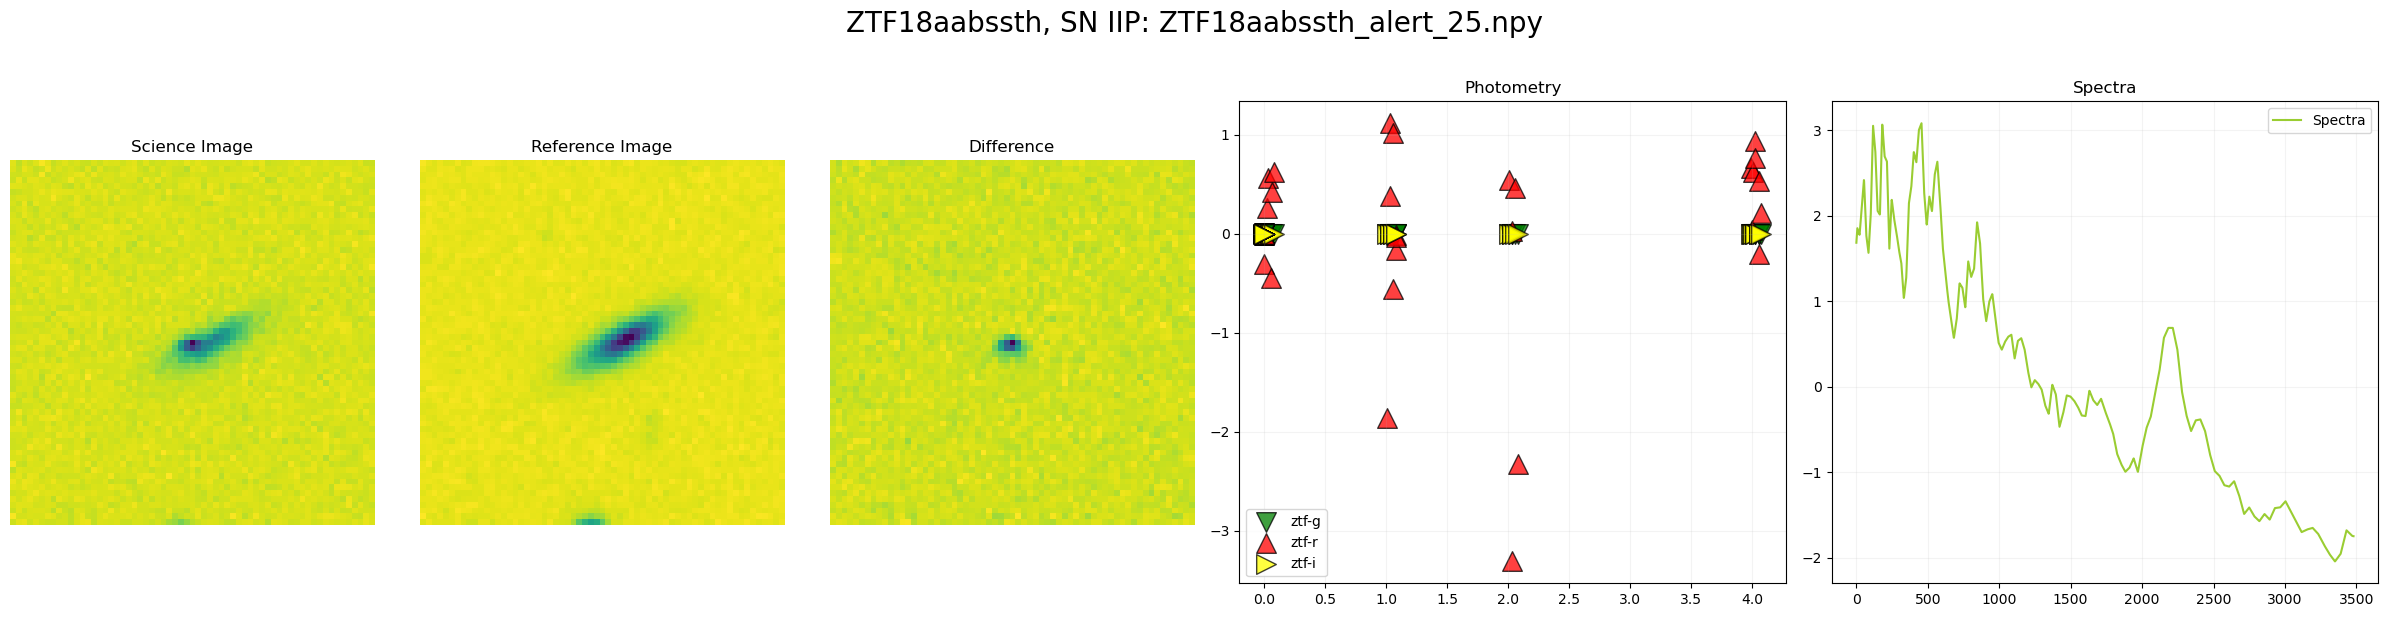

ZTF18aabssth: ZTF18aabssth_alert_26.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,  -0.9901,  -8.9276,  -0.6066,  -0.4089, -22.2515,
        -88.0978,  -0.4212,  -0.4935])


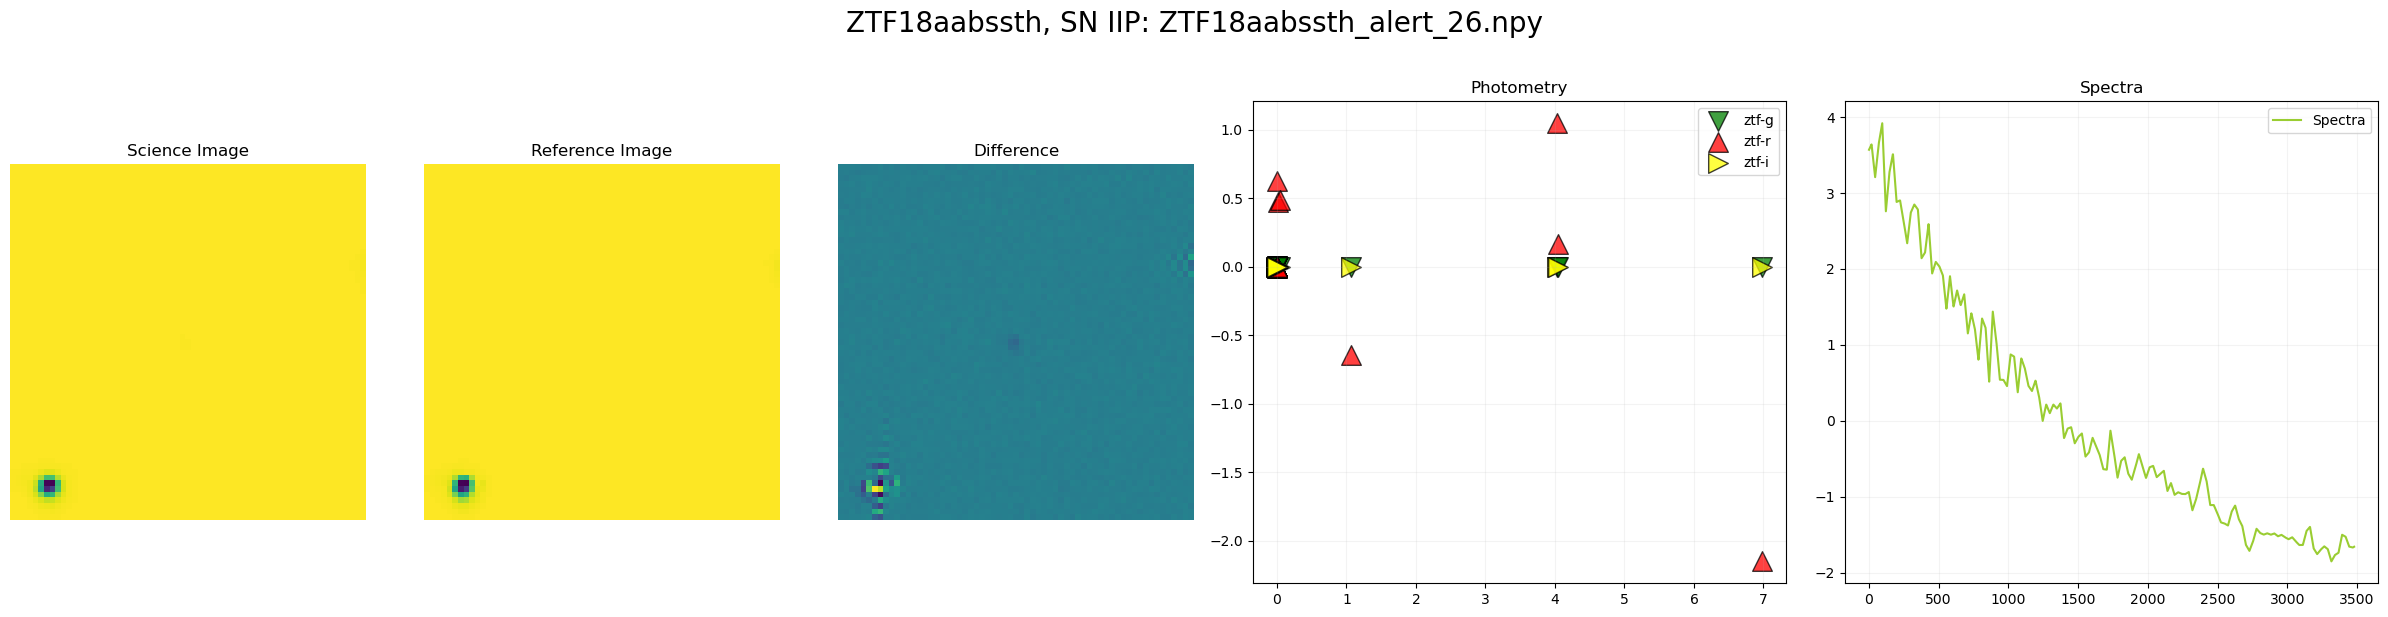

ZTF18aabvpbb: ZTF18aabvpbb_alert_1.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.8802,  -8.9276,  -0.2755,  -0.6996, -22.2515,
          0.0273,  -0.4131,   0.1856])


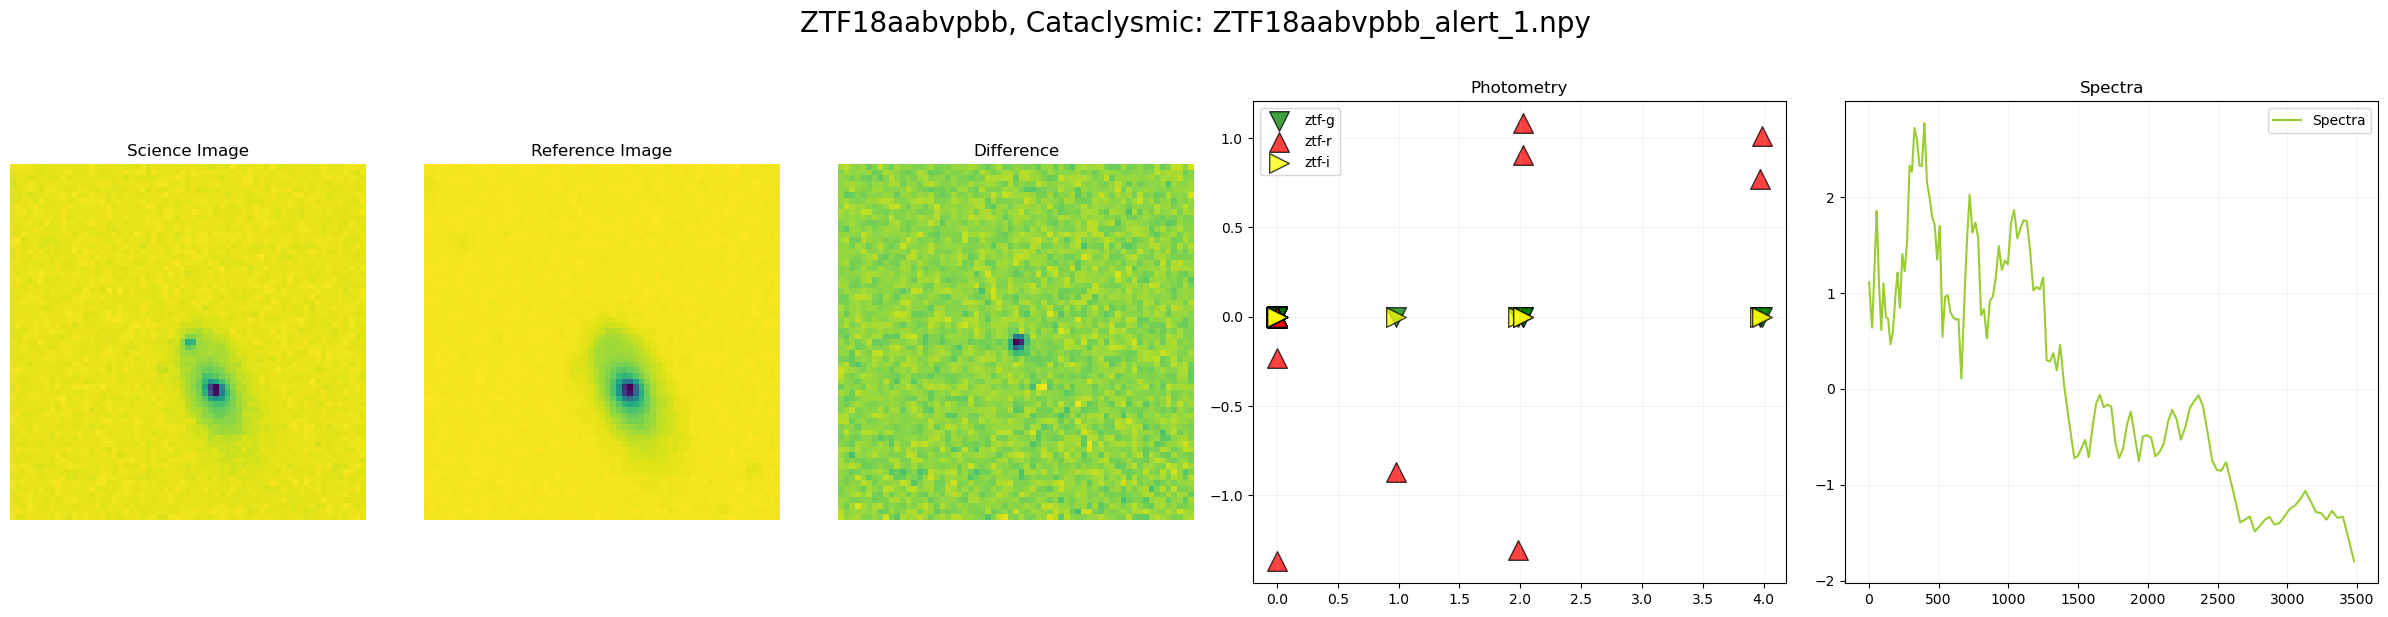

ZTF18aabxlsv: ZTF18aabxlsv_alert_3.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([-22.7328,  -8.9390,   0.8600,  -8.9276,  -0.2755,  -0.6996, -22.2515,
          0.0273,  -0.4154,  -0.3938])


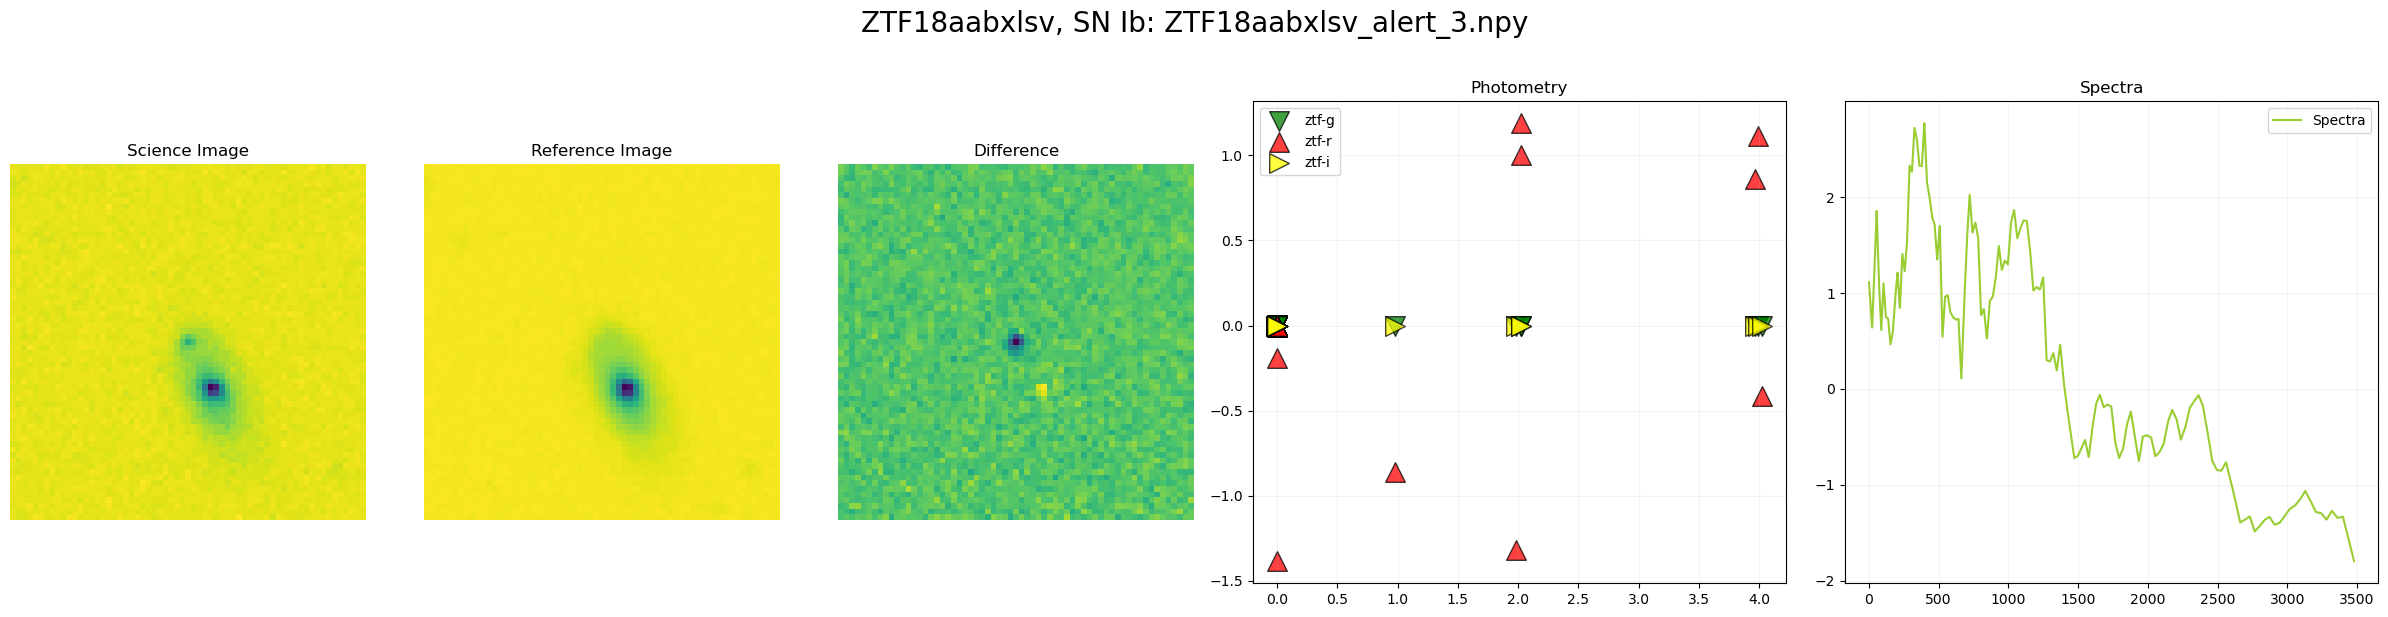

In [15]:
## plot however many you feel like waiting for 
for i in range(20,50):
    plot_dataset.plot_dataset_item(train_dataset, i, data_train)

<big>part 2: DataLoader</big>
<a id='dataload'></a>

***
<i><small>[back to index](#index)</small></i>

In [16]:
train_dataloader = DataLoader(train_dataset, batch_size=config['batch_size'], collate_fn = drink.collate_func,
                              shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=config['batch_size'], collate_fn = drink.collate_func,
                              shuffle=True)

In [17]:
batch = next(iter(train_dataloader))
photometry, photometry_mask, metadata, images, spectra, target  = batch

In [18]:
photometry.shape, photometry_mask.shape, metadata.shape, images.shape, spectra.shape, target.shape

(torch.Size([512, 225, 4]),
 torch.Size([512, 225, 4]),
 torch.Size([512, 10]),
 torch.Size([512, 3, 63, 63]),
 torch.Size([512, 1, 3481]),
 torch.Size([512]))

In [ ]:
drink.run(config)

Using cpu


Train:   0%|          | 0/15 [00:00<?, ?it/s]